# Atmika Khandelwal
# E23CSEU0868
# B-29
# Lab-3

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn nltk opencv-python pillow wfdb neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 48.1 MB/s eta 0:00:00


# Pima Indians Diabetes Dataset(Tabular)

In [ ]:
import os
import re
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Statistics
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

# Machine learning / preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Signal
from scipy.signal import butter, filtfilt, find_peaks
import wfdb

# Image
from PIL import Image, ImageOps

sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print("Path to dataset files:", path)

100%|██████████| 9.13k/9.13k [00:00<00:00, 18.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/versions/1


In [ ]:
import os

print("Files in downloaded dataset:")

for file in os.listdir(path):
    print(file)

Files in downloaded dataset:
diabetes.csv


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nStatistical summary:")
display(df.describe())

Shape of dataset:
(768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Invalid zero values:\n")

for column in clinical_columns:
    print(column, ":", (df[column] == 0).sum())

Invalid zero values:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


In [ ]:
import numpy as np

df_clean = df.copy()

for column in clinical_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Missing values after identifying invalid zeros:")
print(df_clean.isnull().sum())

Missing values after identifying invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
for column in clinical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print("Checking for negative values:\n")

for column in clinical_columns:
    print(
        column,
        ":",
        (df_clean[column] < 0).sum()
    )

Checking for negative values:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


In [ ]:
print("Glucose <= 0:",
      (df_clean["Glucose"] <= 0).sum())

print("BloodPressure <= 0:",
      (df_clean["BloodPressure"] <= 0).sum())

print("BMI <= 0:",
      (df_clean["BMI"] <= 0).sum())

print("Age <= 0:",
      (df_clean["Age"] <= 0).sum())

Glucose <= 0: 0
BloodPressure <= 0: 0
BMI <= 0: 0
Age <= 0: 0


In [ ]:
print("Total missing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("\nCleaned dataset:")
display(df_clean.head())

Total missing values after cleaning:
0

Cleaned dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Class counts:")
print(df_clean["Outcome"].value_counts())

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
print("\nClass percentages:")

class_percentage = (
    df_clean["Outcome"]
    .value_counts(normalize=True)
    * 100
)

print(class_percentage)


Class percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


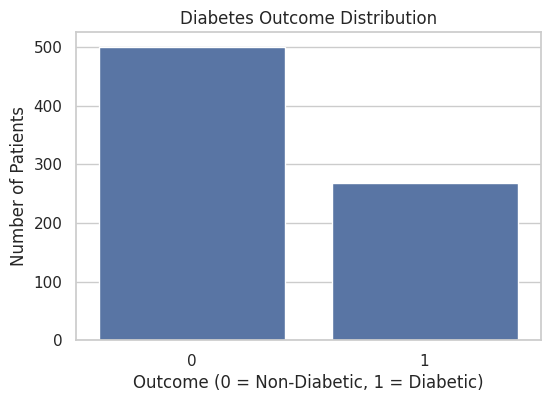

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="Outcome"
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

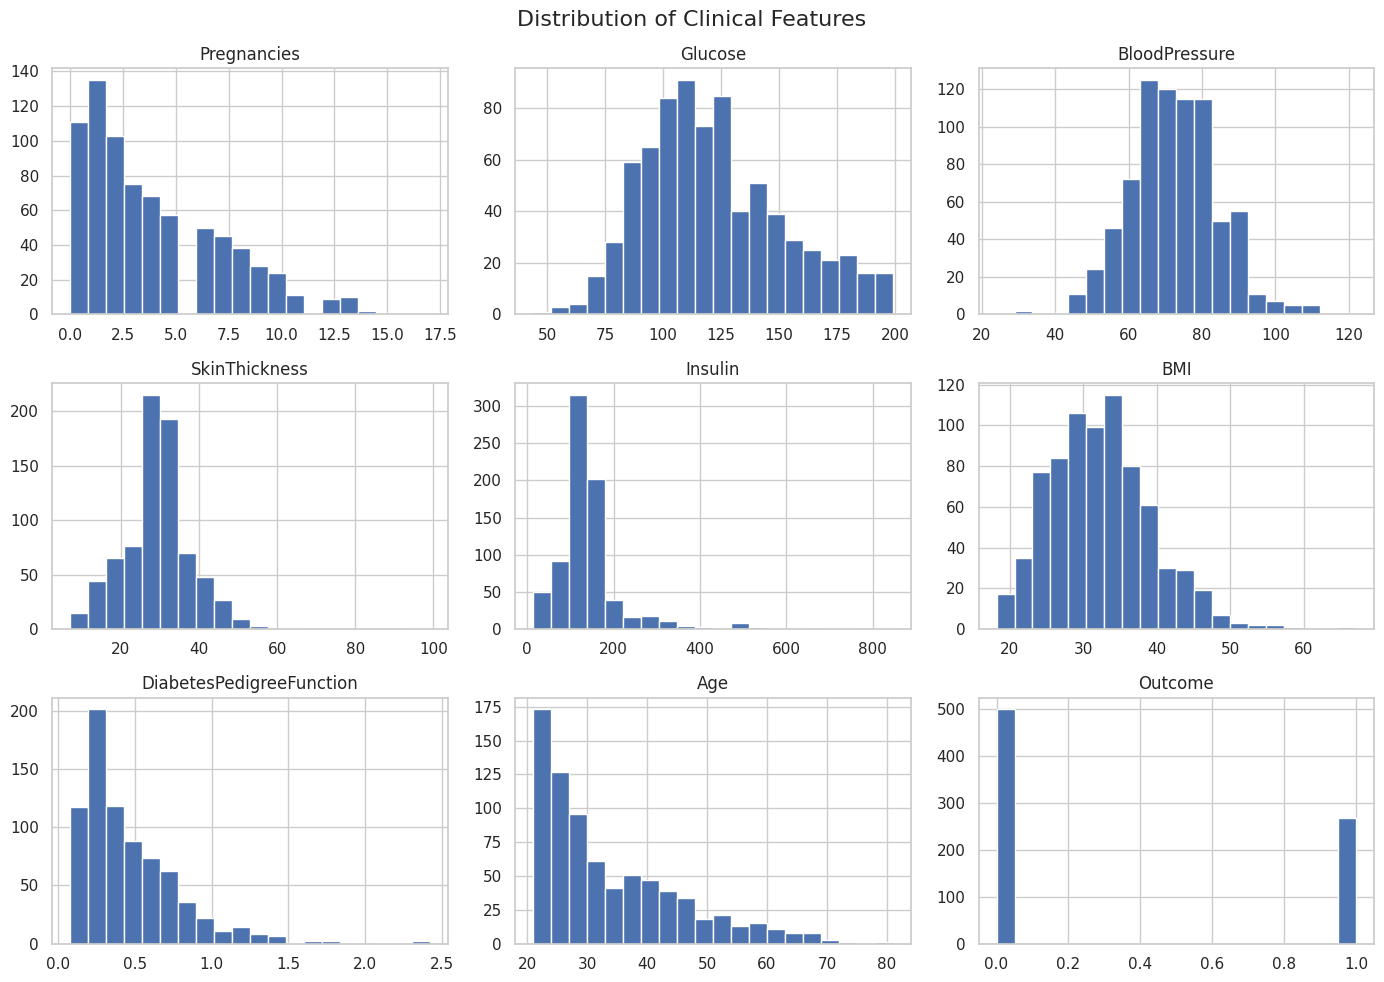

In [ ]:
df_clean.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Clinical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

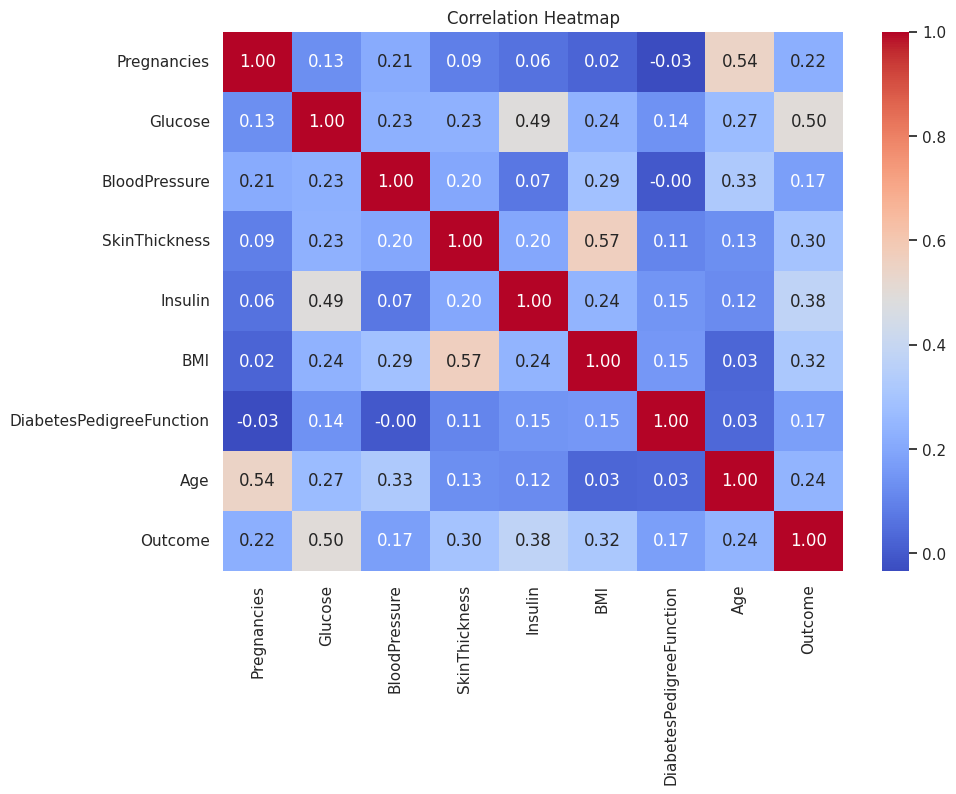

In [ ]:
plt.figure(figsize=(10, 7))

correlation_matrix = df_clean.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

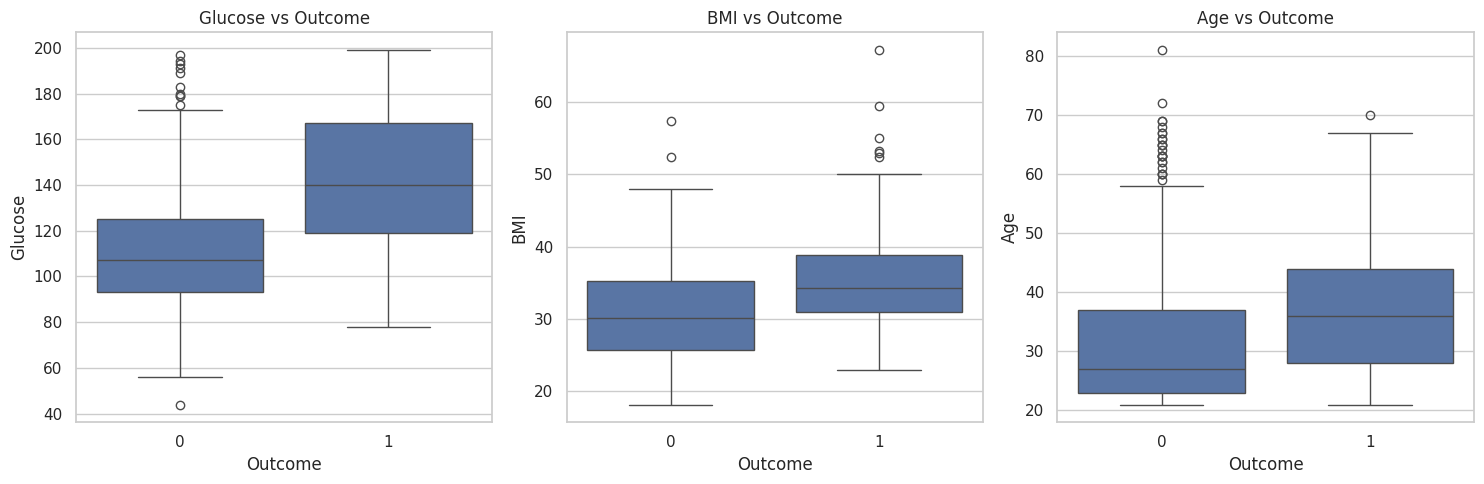

In [ ]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Glucose",
    ax=axes[0]
)

axes[0].set_title("Glucose vs Outcome")

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="BMI",
    ax=axes[1]
)

axes[1].set_title("BMI vs Outcome")

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Age",
    ax=axes[2]
)

axes[2].set_title("Age vs Outcome")

plt.tight_layout()
plt.show()

In [ ]:
df_engineered = df_clean.copy()

df_engineered["BMI_Category"] = pd.cut(
    df_engineered["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

display(
    df_engineered[
        ["BMI", "BMI_Category"]
    ].head()
)

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese


In [ ]:
df_engineered["Age_Group"] = pd.cut(
    df_engineered["Age"],
    bins=[0, 30, 40, 50, np.inf],
    labels=[
        "Young",
        "Adult",
        "Middle_Aged",
        "Older"
    ]
)

display(
    df_engineered[
        ["Age", "Age_Group"]
    ].head()
)

,Age,Age_Group
0,50,Middle_Aged
1,31,Adult
2,32,Adult
3,21,Young
4,33,Adult


In [ ]:
df_engineered["Glucose_Risk"] = pd.cut(
    df_engineered["Glucose"],
    bins=[0, 99, 125, np.inf],
    labels=[
        "Normal",
        "Prediabetic",
        "High"
    ]
)

display(
    df_engineered[
        ["Glucose", "Glucose_Risk"]
    ].head()
)

,Glucose,Glucose_Risk
0,148,High
1,85,Normal
2,183,High
3,89,Normal
4,137,High


In [ ]:
display(df_engineered.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Risk
0,6,148,72.0,35,169.5,33.6,0.627,50,1,Obese,Middle_Aged,High
1,1,85,66.0,29,102.5,26.6,0.351,31,0,Overweight,Adult,Normal
2,8,183,64.0,32,169.5,23.3,0.672,32,1,Normal,Adult,High
3,1,89,66.0,23,94.0,28.1,0.167,21,0,Overweight,Young,Normal
4,0,137,40.0,35,168.0,43.1,2.288,33,1,Obese,Adult,High


In [ ]:
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

X = df_clean.drop(
    columns=["Outcome"]
)

y = df_clean["Outcome"]

selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

X_selected = selector.fit_transform(
    X,
    y
)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information_Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Mutual_Information_Score",
    ascending=False
)

display(feature_scores)

,Feature,Mutual_Information_Score
4,Insulin,0.332470
3,SkinThickness,0.142628
1,Glucose,0.136358
5,BMI,0.085958
7,Age,0.061166
2,BloodPressure,0.050052
0,Pregnancies,0.043976
6,DiabetesPedigreeFunction,0.016059


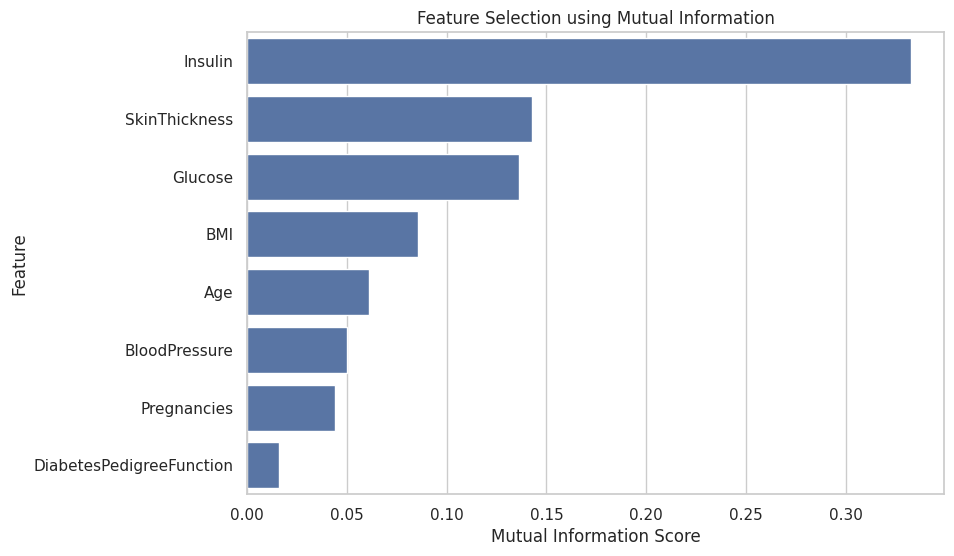

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_scores,
    x="Mutual_Information_Score",
    y="Feature"
)

plt.title("Feature Selection using Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(
    columns=["Outcome"]
)

y = df_clean["Outcome"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (768, 8)
Scaled shape: (768, 8)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print("PCA shape:")
print(X_pca.shape)

PCA shape:
(768, 2)


In [ ]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.29817668 0.18752573]

Total explained variance:
0.4857024053046952


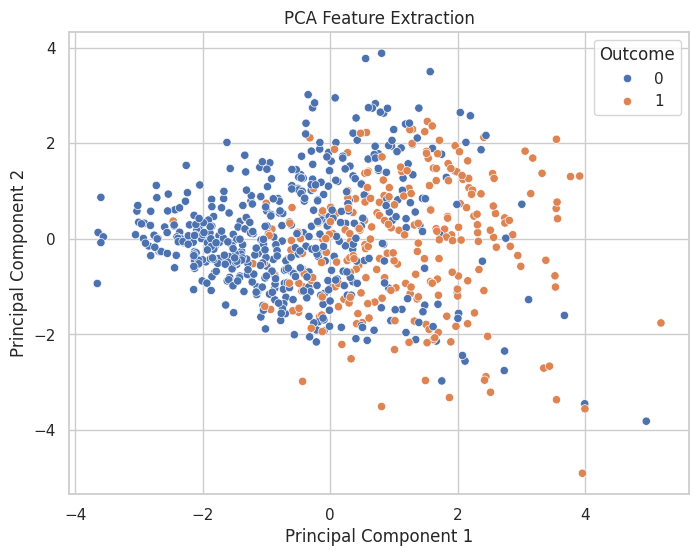

In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Outcome"] = y.values

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Outcome"
)

plt.title("PCA Feature Extraction")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
from scipy.stats import ttest_ind

diabetic_glucose = df_clean[
    df_clean["Outcome"] == 1
]["Glucose"]

non_diabetic_glucose = df_clean[
    df_clean["Outcome"] == 0
]["Glucose"]

t_statistic, p_value = ttest_ind(
    diabetic_glucose,
    non_diabetic_glucose,
    equal_var=False
)

print("Independent Samples t-test:-")

print("t-statistic:", t_statistic)
print("p-value:", p_value)

Independent Samples t-test:-
t-statistic: 14.992112521284485
p-value: 8.301766379086572e-42


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "There is a statistically significant "
        "difference in mean glucose levels between "
        "diabetic and non-diabetic patients."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "There is no statistically significant "
        "difference in mean glucose levels."
    )


Decision: Reject H0
There is a statistically significant difference in mean glucose levels between diabetic and non-diabetic patients.


In [ ]:
from scipy.stats import chi2_contingency

chi_data = df_engineered[
    ["BMI_Category", "Outcome"]
].dropna()

contingency_table = pd.crosstab(
    chi_data["BMI_Category"],
    chi_data["Outcome"]
)

print("Contingency Table:")
display(contingency_table)

Contingency Table:


Outcome,0,1
BMI_Category,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217


In [ ]:
chi2_statistic, p_value, degrees_of_freedom, expected = (
    chi2_contingency(contingency_table)
)

print("Chi-Square Test:- ")
print("Chi-square statistic:", chi2_statistic)
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value)

Chi-Square Test:- 
Chi-square statistic: 73.13331881767633
Degrees of freedom: 3
p-value: 9.101656268510895e-16


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "BMI category and diabetes outcome "
        "are significantly associated."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "BMI category and diabetes outcome "
        "are not significantly associated."
    )


Decision: Reject H0
BMI category and diabetes outcome are significantly associated.


In [ ]:
from scipy.stats import f_oneway

anova_data = df_engineered[
    ["Age_Group", "Glucose"]
].dropna()

groups = []

for age_group, group_data in anova_data.groupby(
    "Age_Group",
    observed=True
):

    groups.append(
        group_data["Glucose"].values
    )

print("Number of age groups:", len(groups))

Number of age groups: 4


In [ ]:
f_statistic, p_value = f_oneway(
    *groups
)

print("One-Way ANOVA:-")
print("F-statistic:", f_statistic)
print("p-value:", p_value)

One-Way ANOVA:-
F-statistic: 20.04913791927765
p-value: 1.623082687221455e-12


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "At least one age group has a "
        "significantly different mean glucose level."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "There is no statistically significant "
        "difference in mean glucose levels among "
        "the age groups."
    )


Decision: Reject H0
At least one age group has a significantly different mean glucose level.


In [ ]:
X = df_clean.drop(
    columns=["Outcome"]
)

y = df_clean["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (614, 8)
Testing features: (154, 8)
Training target: (614,)
Testing target: (154,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaled training data shape:")
print(X_train_scaled.shape)

print("\nScaled testing data shape:")
print(X_test_scaled.shape)

Scaled training data shape:
(614, 8)

Scaled testing data shape:
(154, 8)


In [ ]:
model_ready_train = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("Model-ready training data:")
display(model_ready_train.head())

Model-ready training data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
1,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
2,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
3,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
4,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


In [ ]:
print("Final model-ready data:-")


print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

print("\nMissing values in X_train:")
print(np.isnan(X_train_scaled).sum())

print("\nMissing values in X_test:")
print(np.isnan(X_test_scaled).sum())

Final model-ready data:-
X_train: (614, 8)
X_test : (154, 8)

Missing values in X_train:
0

Missing values in X_test:
0


# MTSamples Medical Transcriptions(Textual)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print("Path to dataset files:", path)

100%|██████████| 4.85M/4.85M [00:01<00:00, 3.22MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1


In [ ]:
import os

print("Files in downloaded dataset:")

for file in os.listdir(path):
    print(file)

Files in downloaded dataset:
mtsamples.csv


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "mtsamples.csv")

df_text = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
print("Dataset shape:")
print(df_text.shape)

print("\nColumn names:")
print(df_text.columns.tolist())

print("\nData types:")
print(df_text.dtypes)

print("\nFirst 5 records:")
display(df_text.head())

print("\nStatistical/structural summary:")
display(df_text.describe(include="all"))

Dataset shape:
(4999, 6)

Column names:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Data types:
Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

First 5 records:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



Statistical/structural summary:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Missing values:")
print(df_text.isnull().sum())

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [ ]:
print("Number of duplicate rows:")
print(df_text.duplicated().sum())

Number of duplicate rows:
0


In [ ]:
df_text = df_text.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:")
print(df_text.shape)

Shape after removing duplicates:
(4999, 6)


In [ ]:
print("Columns:")
print(df_text.columns.tolist())

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [ ]:
print("Missing transcriptions:")
print(df_text["transcription"].isnull().sum())

Missing transcriptions:
33


In [ ]:
df_text = df_text.dropna(
    subset=["transcription"]
).reset_index(drop=True)

print("Shape after removing missing transcriptions:")
print(df_text.shape)

Shape after removing missing transcriptions:
(4966, 6)


In [ ]:
import re

In [ ]:
def remove_phi(text):
    text = str(text)

    # Remove email addresses
    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        ' ',
        text
    )

    # Remove phone numbers
    text = re.sub(
        r'\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)\d{3}[-.\s]?\d{4}\b',
        ' ',
        text
    )

    # Remove URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Remove dates such as 01/12/2020, 01-12-2020
    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' ',
        text
    )

    # Remove SSN-like numbers
    text = re.sub(
        r'\b\d{3}-\d{2}-\d{4}\b',
        ' ',
        text
    )

    # Remove common patient-identifying labels
    text = re.sub(
        r'\b(?:patient\s*name|patient\s*id|mr\.?|mrs\.?|ms\.?|name)\s*[:\-]?\s*[A-Za-z]+(?:\s+[A-Za-z]+){0,2}',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    return text

In [ ]:
df_text["transcription_clean"] = (
    df_text["transcription"]
    .apply(remove_phi)
)

display(
    df_text[
        ["transcription", "transcription_clean"]
    ].head()
)

,transcription,transcription_clean
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...


In [ ]:
df_text["transcription_clean"] = (
    df_text["transcription_clean"]
    .str.lower()
)

In [ ]:
df_text["transcription_clean"] = (
    df_text["transcription_clean"]
    .str.replace(
        r'[^a-zA-Z\s]',
        ' ',
        regex=True
    )
)

In [ ]:
df_text["transcription_clean"] = (
    df_text["transcription_clean"]
    .str.replace(
        r'\s+',
        ' ',
        regex=True
    )
    .str.strip()
)

In [ ]:
display(
    df_text[
        ["transcription", "transcription_clean"]
    ].head()
)

,transcription,transcription_clean
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this year old white female presents...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode left atrial enlargement with left atr...
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...


In [ ]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize

df_text["tokens"] = (
    df_text["transcription_clean"]
    .apply(word_tokenize)
)

display(
    df_text[
        ["transcription_clean", "tokens"]
    ].head()
)

,transcription_clean,tokens
0,subjective this year old white female presents...,"[subjective, this, year, old, white, female, p..."
1,past medical history he has difficulty climbin...,"[past, medical, history, he, has, difficulty, ..."
2,history of present illness i have seen abc tod...,"[history, of, present, illness, i, have, seen,..."
3,d m mode left atrial enlargement with left atr...,"[d, m, mode, left, atrial, enlargement, with, ..."
4,the left ventricular cavity size and wall thic...,"[the, left, ventricular, cavity, size, and, wa..."


In [ ]:
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words("english")
)

df_text["tokens_clean"] = df_text["tokens"].apply(
    lambda tokens: [
        word
        for word in tokens
        if word not in stop_words
    ]
)


In [ ]:
display(
    df_text[
        ["tokens", "tokens_clean"]
    ].head()
)

,tokens,tokens_clean
0,"[subjective, this, year, old, white, female, p...","[subjective, year, old, white, female, present..."
1,"[past, medical, history, he, has, difficulty, ...","[past, medical, history, difficulty, climbing,..."
2,"[history, of, present, illness, i, have, seen,...","[history, present, illness, seen, abc, today, ..."
3,"[d, m, mode, left, atrial, enlargement, with, ...","[mode, left, atrial, enlargement, left, atrial..."
4,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn..."


In [ ]:
df_text["word_count"] = (
    df_text["tokens_clean"]
    .apply(len)
)

df_text["character_count"] = (
    df_text["transcription_clean"]
    .str.len()
)

display(
    df_text[
        ["word_count", "character_count"]
    ].describe()
)

,word_count,character_count
count,4966.000000,4966.000000
mean,274.876359,2874.402135
std,176.318177,1891.865496
min,1.000000,9.000000
25%,146.000000,1509.000000
50%,243.000000,2490.000000
75%,360.000000,3791.500000
max,1572.000000,16936.000000


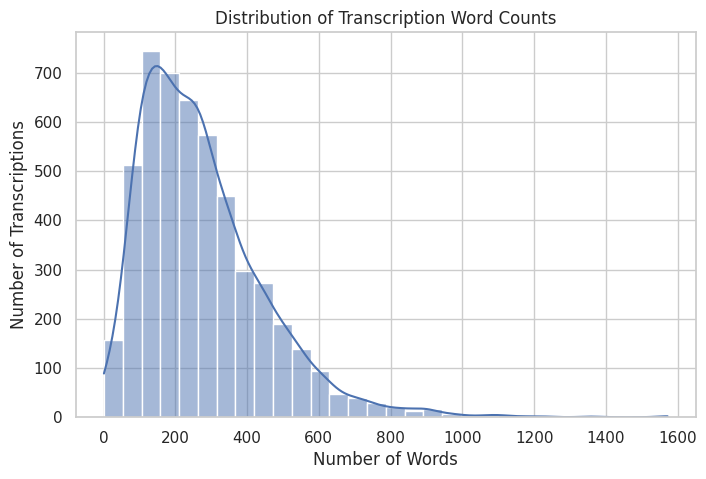

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df_text["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Transcription Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Transcriptions")

plt.show()

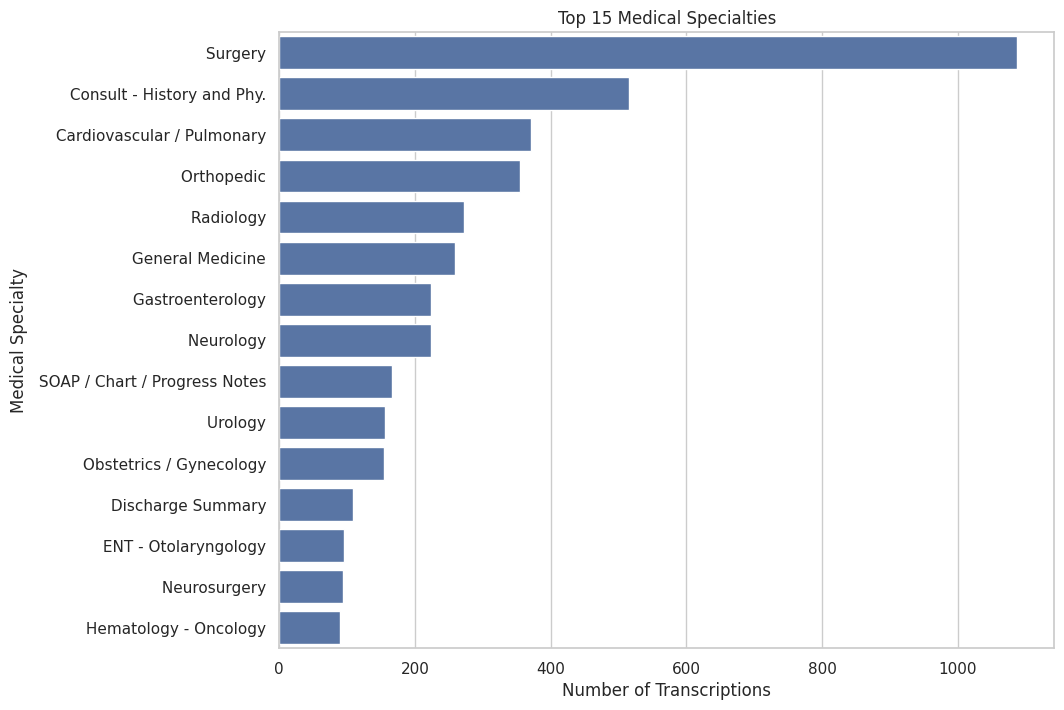

In [ ]:
plt.figure(figsize=(10, 8))

specialty_counts = (
    df_text["medical_specialty"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=specialty_counts.values,
    y=specialty_counts.index
)

plt.title("Top 15 Medical Specialties")
plt.xlabel("Number of Transcriptions")
plt.ylabel("Medical Specialty")

plt.show()

In [ ]:
print("Medical specialty distribution:")

display(
    df_text["medical_specialty"]
    .value_counts()
)

Medical specialty distribution:


,count
medical_specialty,
Surgery,1088
Consult - History and Phy.,516
Cardiovascular / Pulmonary,371
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,224
Neurology,223
SOAP / Chart / Progress Notes,166


In [ ]:
from collections import Counter

all_words = []

for tokens in df_text["tokens_clean"]:
    all_words.extend(tokens)

word_counts = Counter(all_words)

most_common_words = (
    word_counts
    .most_common(20)
)

print("Top 20 most frequent words:")

for word, count in most_common_words:
    print(word, ":", count)

Top 20 most frequent words:
patient : 24165
right : 11577
left : 11243
history : 9509
normal : 7524
procedure : 7426
placed : 7022
well : 6608
pain : 5974
mg : 4375
x : 4354
noted : 4346
also : 4329
time : 4285
using : 4123
c : 4114
blood : 3956
performed : 3920
skin : 3798
without : 3726


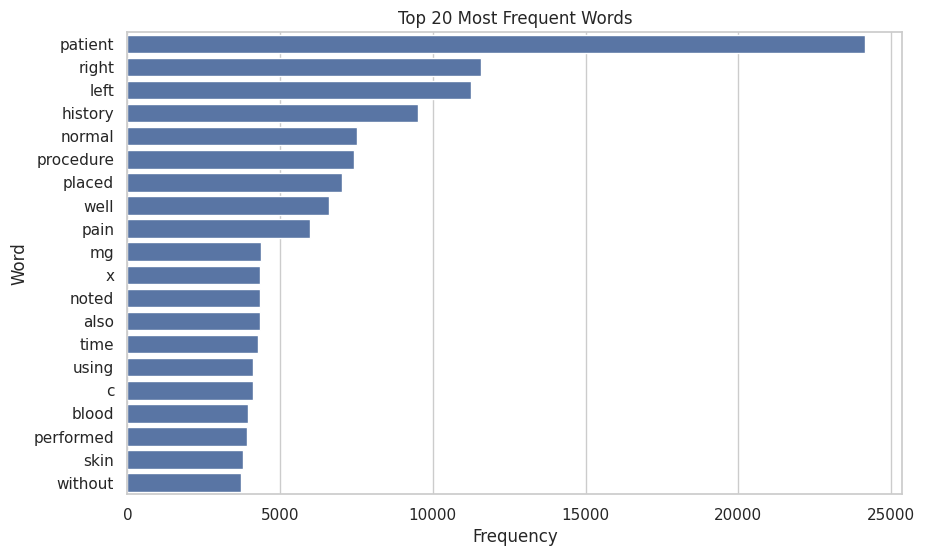

In [ ]:
words = [
    item[0]
    for item in most_common_words
]

counts = [
    item[1]
    for item in most_common_words
]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
df_text["unique_word_count"] = (
    df_text["tokens_clean"]
    .apply(lambda x: len(set(x)))
)

df_text["average_word_length"] = (
    df_text.apply(
        lambda row:
        sum(len(word) for word in row["tokens_clean"])
        / len(row["tokens_clean"])
        if len(row["tokens_clean"]) > 0
        else 0,
        axis=1
    )
)

In [ ]:
display(
    df_text[
        [
            "word_count",
            "character_count",
            "unique_word_count",
            "average_word_length"
        ]
    ].head()
)

,word_count,character_count,unique_word_count,average_word_length
0,117,1247,94,6.358974
1,239,2271,197,6.778243
2,437,4117,312,6.226545
3,50,426,32,6.640000
4,157,1523,95,7.114650


In [ ]:
display(
    df_text[
        [
            "word_count",
            "character_count",
            "unique_word_count",
            "average_word_length"
        ]
    ].describe()
)

,word_count,character_count,unique_word_count,average_word_length
count,4966.000000,4966.000000,4966.000000,4966.000000
mean,274.876359,2874.402135,175.466573,6.843412
std,176.318177,1891.865496,95.627963,0.466874
min,1.000000,9.000000,1.000000,4.375000
25%,146.000000,1509.000000,102.250000,6.563758
50%,243.000000,2490.000000,162.000000,6.838708
75%,360.000000,3791.500000,231.000000,7.100324
max,1572.000000,16936.000000,692.000000,12.400000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf_vectorizer.fit_transform(
    df_text["transcription_clean"]
)

print("TF-IDF matrix shape:")
print(X_tfidf.shape)

TF-IDF matrix shape:
(4966, 5000)


In [ ]:
feature_names = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print("Number of extracted features:")
print(len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of extracted features:
5000

First 30 features:
['abc' 'abcd' 'abcd general' 'abdomen' 'abdomen and' 'abdomen is'
 'abdomen soft' 'abdomen the' 'abdomen was' 'abdominal' 'abdominal cavity'
 'abdominal pain' 'abdominal wall' 'able' 'able to' 'abnormal'
 'abnormalities' 'abnormality' 'about' 'about cm' 'about the' 'above'
 'above the' 'abscess' 'absent' 'abuse' 'access' 'accident'
 'accommodation' 'accomplished']


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
y_text = df_text[
    "medical_specialty"
].astype(str)

In [ ]:
valid_rows = (
    df_text["medical_specialty"]
    .notna()
)

X_tfidf_valid = X_tfidf[
    valid_rows.to_numpy()
]

y_text_valid = y_text[
    valid_rows
]

print("Feature matrix shape:")
print(X_tfidf_valid.shape)

print("\nTarget shape:")
print(y_text_valid.shape)

Feature matrix shape:
(4966, 5000)

Target shape:
(4966,)


In [ ]:
k = min(
    1000,
    X_tfidf_valid.shape[1]
)

selector = SelectKBest(
    score_func=chi2,
    k=k
)

X_selected = selector.fit_transform(
    X_tfidf_valid,
    y_text_valid
)

print("Original TF-IDF shape:")
print(X_tfidf_valid.shape)

print("\nSelected feature shape:")
print(X_selected.shape)

Original TF-IDF shape:
(4966, 5000)

Selected feature shape:
(4966, 1000)


In [ ]:
selected_features = (
    feature_names[
        selector.get_support()
    ]
)

print("First 50 selected features:")

print(
    selected_features[:50]
)

First 50 selected features:
['abc' 'abdomen' 'abdomen and' 'abdomen soft' 'abdomen was' 'abdominal'
 'able' 'able to' 'abscess' 'absent' 'activities' 'activity'
 'adenocarcinoma' 'adenoid' 'admission' 'admitted' 'adnexal' 'advanced'
 'age' 'alcohol' 'alert' 'allergies' 'allergy' 'allograft' 'amplitude'
 'and draped' 'and pelvis' 'and rhythm' 'and the' 'and throat'
 'anesthesia' 'anesthesia local' 'ankle' 'ankle tourniquet' 'anterior'
 'anterior cervical' 'anterior chamber' 'anterior descending' 'anxiety'
 'any' 'aorta' 'aortic' 'aortic valve' 'aphasia' 'apnea' 'appendicitis'
 'appendix' 'applied' 'approach' 'april']


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
df_text["token_text"] = (
    df_text["tokens_clean"]
    .apply(
        lambda tokens: " ".join(tokens)
    )
)

In [ ]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df_text["token_text"]
)

sequences = tokenizer.texts_to_sequences(
    df_text["token_text"]
)

print("Number of sequences:")
print(len(sequences))

Number of sequences:
4966


In [ ]:
max_length = 300

X_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Token sequence shape:")
print(X_sequences.shape)

Token sequence shape:
(4966, 300)


In [ ]:
print("First token sequence:")
print(X_sequences[0])

First token sequence:
[ 993   26   28  205  132  532  381  134   24  134 5180 9524 2732  881
   36 1715 3512 3377 1539  677   15 1680 3647    1   24 3562   14   24
  169 5296  649   16   40  176  214  641 1223    9   24 2510 5297 1097
  244 5297 1195    1 1616   97  470  914 7693   57  470  327 6502 9110
    1 3562  134  413 1880  134 1344 2236  163  406   18   54  270  549
 1103 3811   21 2062  244  488 3811 2542   68  678   90 1661   68   48
  486   21  875  322   68  289 1111 2354  107 1423 3377 3914 3562  872
 2908  147 9525  914 1097 3724 1637    1 3198 7694   40 5297 4493   74
  172  176 1097 1729    9    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df_text["medical_specialty"].astype(str)
)

print("Number of classes:")
print(len(label_encoder.classes_))

print("\nMedical specialty classes:")
print(label_encoder.classes_)

Number of classes:
40

Medical specialty classes:
[' Allergy / Immunology' ' Autopsy' ' Bariatrics'
 ' Cardiovascular / Pulmonary' ' Chiropractic'
 ' Consult - History and Phy.' ' Cosmetic / Plastic Surgery' ' Dentistry'
 ' Dermatology' ' Diets and Nutritions' ' Discharge Summary'
 ' ENT - Otolaryngology' ' Emergency Room Reports' ' Endocrinology'
 ' Gastroenterology' ' General Medicine' ' Hematology - Oncology'
 ' Hospice - Palliative Care' ' IME-QME-Work Comp etc.'
 ' Lab Medicine - Pathology' ' Letters' ' Nephrology' ' Neurology'
 ' Neurosurgery' ' Obstetrics / Gynecology' ' Office Notes'
 ' Ophthalmology' ' Orthopedic' ' Pain Management'
 ' Pediatrics - Neonatal' ' Physical Medicine - Rehab' ' Podiatry'
 ' Psychiatry / Psychology' ' Radiology' ' Rheumatology'
 ' SOAP / Chart / Progress Notes' ' Sleep Medicine' ' Speech - Language'
 ' Surgery' ' Urology']


In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = (
    train_test_split(
        X_sequences,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )
)

print("Training text shape:")
print(X_train_text.shape)

print("Testing text shape:")
print(X_test_text.shape)

print("Training labels:")
print(y_train_text.shape)

print("Testing labels:")
print(y_test_text.shape)

Training text shape:
(3972, 300)
Testing text shape:
(994, 300)
Training labels:
(3972,)
Testing labels:
(994,)


In [ ]:
print("FINAL MODEL-READY TEXT DATA:-")

print("Vocabulary size:",
      len(tokenizer.word_index) + 1)

print("Maximum sequence length:",
      max_length)

print("Training data:",
      X_train_text.shape)

print("Testing data:",
      X_test_text.shape)

print("Number of classes:",
      len(label_encoder.classes_))

FINAL MODEL-READY TEXT DATA:-
Vocabulary size: 20822
Maximum sequence length: 300
Training data: (3972, 300)
Testing data: (994, 300)
Number of classes: 40


In [ ]:
print("\nMissing values in original transcription:")
print(
    df_text["transcription"].isnull().sum()
)

print("\nMissing values in cleaned transcription:")
print(
    df_text["transcription_clean"].isnull().sum()
)

print("\nEmpty cleaned transcriptions:")
print(
    (
        df_text["transcription_clean"].str.strip() == ""
    ).sum()
)


Missing values in original transcription:
0

Missing values in cleaned transcription:
0

Empty cleaned transcriptions:
0


# Chest X-Ray Pneumonia Dataset(Image)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os

# Actual dataset root
dataset_root = os.path.join(path, "chest_xray")

print("Dataset root:", dataset_root)

print("\nContents of dataset root:")
for item in os.listdir(dataset_root):
    print(item)

Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray

Contents of dataset root:
chest_xray
__MACOSX
val
test
train


In [ ]:
dataset_counts = {}

for split in ["train", "test", "val"]:

    split_path = os.path.join(
        dataset_root,
        split
    )

    class_counts = {}

    for class_name in ["NORMAL", "PNEUMONIA"]:

        class_path = os.path.join(
            split_path,
            class_name
        )

        if os.path.exists(class_path):

            image_count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                )
            ])

            class_counts[class_name] = image_count

    dataset_counts[split] = class_counts


print("Image counts:")
print(dataset_counts)

Image counts:
{'train': {'NORMAL': 1341, 'PNEUMONIA': 3875}, 'test': {'NORMAL': 234, 'PNEUMONIA': 390}, 'val': {'NORMAL': 8, 'PNEUMONIA': 8}}


In [ ]:
import pandas as pd

count_rows = []

for split, classes in dataset_counts.items():

    for class_name, count in classes.items():

        count_rows.append({
            "Dataset": split,
            "Class": class_name,
            "Count": count
        })

count_df = pd.DataFrame(count_rows)

display(count_df)

,Dataset,Class,Count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,test,NORMAL,234
3,test,PNEUMONIA,390
4,val,NORMAL,8
5,val,PNEUMONIA,8


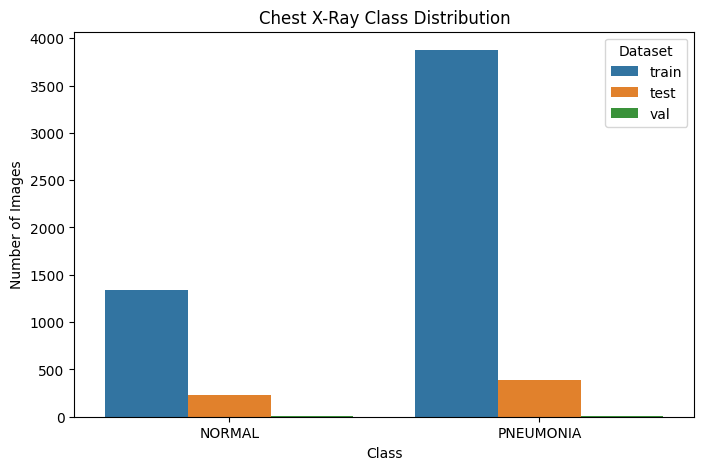

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=count_df,
    x="Class",
    y="Count",
    hue="Dataset"
)

plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
train_counts = dataset_counts["train"]

normal_count = train_counts["NORMAL"]
pneumonia_count = train_counts["PNEUMONIA"]

total_train = normal_count + pneumonia_count

normal_percentage = (
    normal_count / total_train
) * 100

pneumonia_percentage = (
    pneumonia_count / total_train
) * 100

print("Training Dataset Class Distribution")
print("------------------------------------")

print(
    f"NORMAL: {normal_count} "
    f"({normal_percentage:.2f}%)"
)

print(
    f"PNEUMONIA: {pneumonia_count} "
    f"({pneumonia_percentage:.2f}%)"
)

Training Dataset Class Distribution
------------------------------------
NORMAL: 1341 (25.71%)
PNEUMONIA: 3875 (74.29%)


In [ ]:
train_path = os.path.join(
    dataset_root,
    "train"
)

test_path = os.path.join(
    dataset_root,
    "test"
)

val_path = os.path.join(
    dataset_root,
    "val"
)

normal_path = os.path.join(
    train_path,
    "NORMAL"
)

pneumonia_path = os.path.join(
    train_path,
    "PNEUMONIA"
)

print("Train path:", train_path)
print("Test path:", test_path)
print("Validation path:", val_path)

print("\nNormal images path:", normal_path)
print("Pneumonia images path:", pneumonia_path)

Train path: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test path: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Validation path: /kaggle/input/chest-xray-pneumonia/chest_xray/val

Normal images path: /kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL
Pneumonia images path: /kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA


In [ ]:
print("NORMAL folder exists:",
      os.path.exists(normal_path))

print("PNEUMONIA folder exists:",
      os.path.exists(pneumonia_path))

print("TEST folder exists:",
      os.path.exists(test_path))

print("VAL folder exists:",
      os.path.exists(val_path))

NORMAL folder exists: True
PNEUMONIA folder exists: True
TEST folder exists: True
VAL folder exists: True


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

normal_images = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

pneumonia_images = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of NORMAL images:", len(normal_images))
print("Number of PNEUMONIA images:", len(pneumonia_images))

Number of NORMAL images: 1341
Number of PNEUMONIA images: 3875


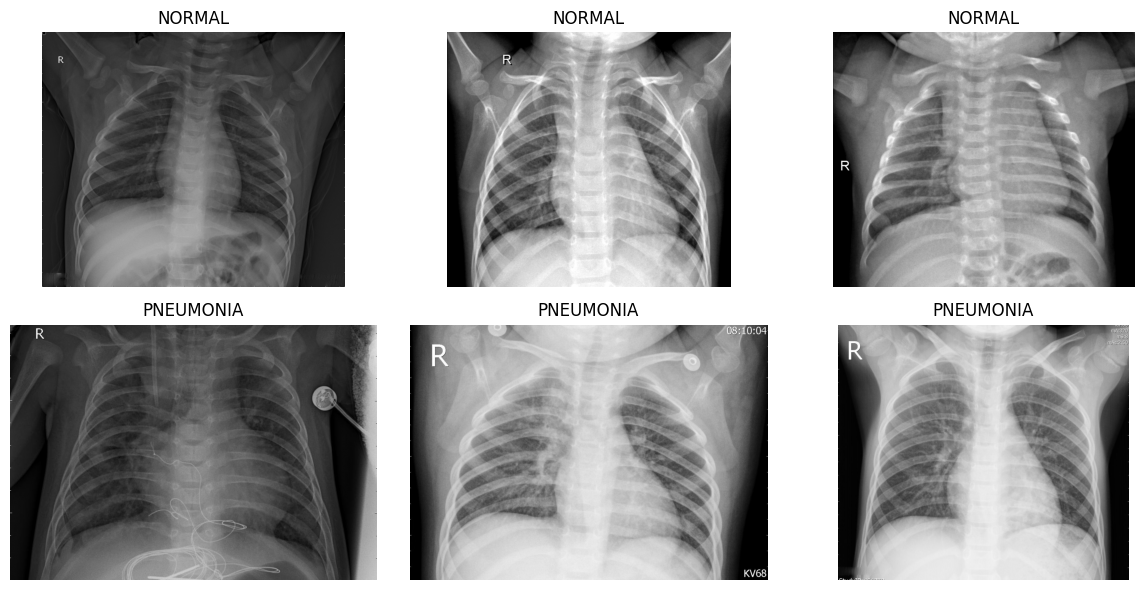

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(3):
    image_path = os.path.join(
        normal_path,
        normal_images[i]
    )

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")


for i in range(3):
    image_path = os.path.join(
        pneumonia_path,
        pneumonia_images[i]
    )

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 4)
    plt.imshow(image, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def inspect_dimensions(folder_path, max_images=100):

    dimensions = []

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    for filename in image_files[:max_images]:

        image_path = os.path.join(
            folder_path,
            filename
        )

        try:
            with Image.open(image_path) as image:
                dimensions.append({
                    "Width": image.width,
                    "Height": image.height,
                    "Mode": image.mode
                })

        except Exception:
            pass

    return pd.DataFrame(dimensions)

In [ ]:
normal_dimensions = inspect_dimensions(
    normal_path
)

pneumonia_dimensions = inspect_dimensions(
    pneumonia_path
)

print("NORMAL image dimensions:")
display(normal_dimensions.head())

print("\nPNEUMONIA image dimensions:")
display(pneumonia_dimensions.head())

NORMAL image dimensions:


,Width,Height,Mode
0,1336,1128,L
1,1400,1260,L
2,1218,1032,L
3,1782,1433,L
4,1574,1129,L



PNEUMONIA image dimensions:


,Width,Height,Mode
0,1024,712,L
1,1424,1016,L
2,1376,1208,L
3,1336,1256,L
4,895,516,RGB


In [ ]:
print("NORMAL dimensions summary:")
display(normal_dimensions[["Width", "Height"]].describe())

print("\nPNEUMONIA dimensions summary:")
display(pneumonia_dimensions[["Width", "Height"]].describe())

NORMAL dimensions summary:


,Width,Height
count,100.000000,100.000000
mean,1626.220000,1337.900000
std,295.711318,314.067628
min,1014.000000,846.000000
25%,1410.000000,1126.250000
50%,1620.000000,1272.000000
75%,1784.000000,1462.000000
max,2633.000000,2578.000000



PNEUMONIA dimensions summary:


,Width,Height
count,100.000000,100.000000
mean,1228.700000,858.440000
std,289.141624,288.248571
min,703.000000,375.000000
25%,1014.500000,668.000000
50%,1180.000000,808.000000
75%,1409.500000,962.000000
max,2080.000000,2032.000000


In [ ]:
sample_normal_path = os.path.join(
    normal_path,
    normal_images[0]
)

with Image.open(sample_normal_path) as image:

    print("Image format:", image.format)
    print("Image mode:", image.mode)
    print("Image size:", image.size)

    exif_data = image.getexif()

    print("\nNumber of EXIF metadata entries:",
          len(exif_data))

Image format: JPEG
Image mode: L
Image size: (1336, 1128)

Number of EXIF metadata entries: 12


In [ ]:
if len(exif_data) > 0:

    print("EXIF metadata:")

    for key, value in exif_data.items():
        print(key, ":", value)

else:

    print("No EXIF metadata found.")

EXIF metadata:
256 : 1336
257 : 1128
258 : (8, 8, 8, 8)
262 : 1
296 : 2
34665 : 236
305 : Adobe Photoshop CS6 (Macintosh)
274 : 1
306 : 2018:01:04 12:58:55
277 : 4
282 : 72.0
283 : 72.0


In [ ]:
def anonymize_image(image_path):

    image = Image.open(
        image_path
    ).convert("L")

    pixel_array = np.array(image)

    anonymized_image = Image.fromarray(
        pixel_array
    )

    return anonymized_image

In [ ]:
import numpy as np
anonymized_image = anonymize_image(
    sample_normal_path
)

print(
    "Metadata entries after anonymization:",
    len(anonymized_image.getexif())
)

Metadata entries after anonymization: 0


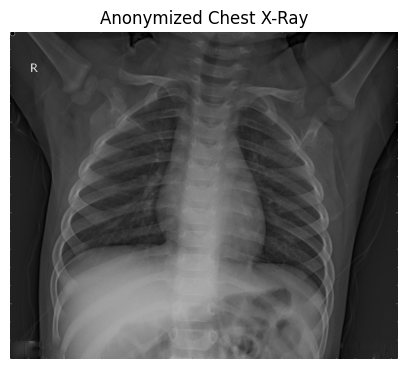

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(
    anonymized_image,
    cmap="gray"
)

plt.title("Anonymized Chest X-Ray")
plt.axis("off")

plt.show()

In [ ]:
def find_corrupt_images(folder_path):

    corrupt_images = []

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    for filename in image_files:

        image_path = os.path.join(
            folder_path,
            filename
        )

        try:

            with Image.open(image_path) as image:
                image.verify()

        except Exception:

            corrupt_images.append(filename)

    return corrupt_images

In [ ]:
normal_corrupt = find_corrupt_images(
    normal_path
)

print(
    "Corrupt NORMAL images:",
    len(normal_corrupt)
)

Corrupt NORMAL images: 0


In [ ]:
pneumonia_corrupt = find_corrupt_images(
    pneumonia_path
)

print(
    "Corrupt PNEUMONIA images:",
    len(pneumonia_corrupt)
)

Corrupt PNEUMONIA images: 0


In [ ]:
IMAGE_SIZE = (224, 224)

def preprocess_image(image_path):

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        IMAGE_SIZE
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_array = image_array / 255.0

    return image_array

In [ ]:
processed_image = preprocess_image(
    sample_normal_path
)

print("Processed image shape:",
      processed_image.shape)

print("Minimum pixel value:",
      processed_image.min())

print("Maximum pixel value:",
      processed_image.max())

Processed image shape: (224, 224)
Minimum pixel value: 0.0
Maximum pixel value: 0.7176471


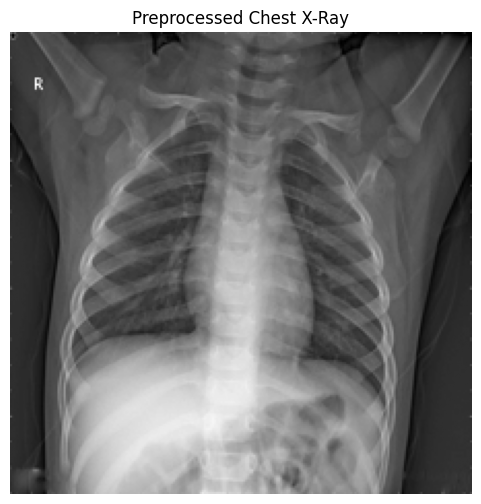

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    processed_image,
    cmap="gray"
)

plt.title(
    "Preprocessed Chest X-Ray"
)

plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


In [ ]:
print("Class names:")
print(train_dataset.class_names)

Class names:
['NORMAL', 'PNEUMONIA']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)

train_dataset_normalized = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

test_dataset_normalized = test_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

val_dataset_normalized = val_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

In [ ]:
sample_batch_images, sample_batch_labels = next(
    iter(train_dataset_normalized)
)

print("Image tensor shape:")
print(sample_batch_images.shape)

print("\nLabel tensor shape:")
print(sample_batch_labels.shape)

print("\nMinimum pixel value:")
print(tf.reduce_min(sample_batch_images).numpy())

print("\nMaximum pixel value:")
print(tf.reduce_max(sample_batch_images).numpy())

Image tensor shape:
(32, 224, 224, 1)

Label tensor shape:
(32, 1)

Minimum pixel value:
0.0

Maximum pixel value:
1.0


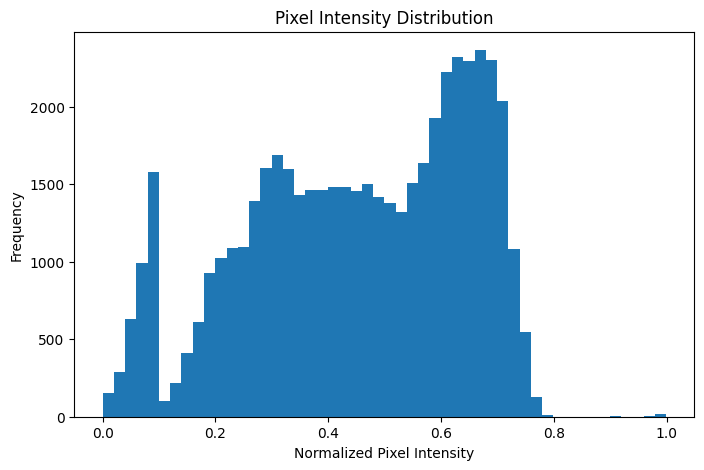

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    sample_batch_images[0].numpy().flatten(),
    bins=50
)

plt.title(
    "Pixel Intensity Distribution"
)

plt.xlabel(
    "Normalized Pixel Intensity"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [ ]:
def load_sample_images(
    folder_path,
    max_images=100
):

    images = []

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    image_files = image_files[:max_images]

    for filename in image_files:

        image_path = os.path.join(
            folder_path,
            filename
        )

        image = preprocess_image(
            image_path
        )

        images.append(image)

    return np.array(images)

In [ ]:
normal_sample_images = load_sample_images(
    normal_path,
    max_images=100
)

pneumonia_sample_images = load_sample_images(
    pneumonia_path,
    max_images=100
)

print(
    "NORMAL sample tensor:",
    normal_sample_images.shape
)

print(
    "PNEUMONIA sample tensor:",
    pneumonia_sample_images.shape
)

NORMAL sample tensor: (100, 224, 224)
PNEUMONIA sample tensor: (100, 224, 224)


In [ ]:
normal_average = normal_sample_images.mean(
    axis=0
)

pneumonia_average = pneumonia_sample_images.mean(
    axis=0
)

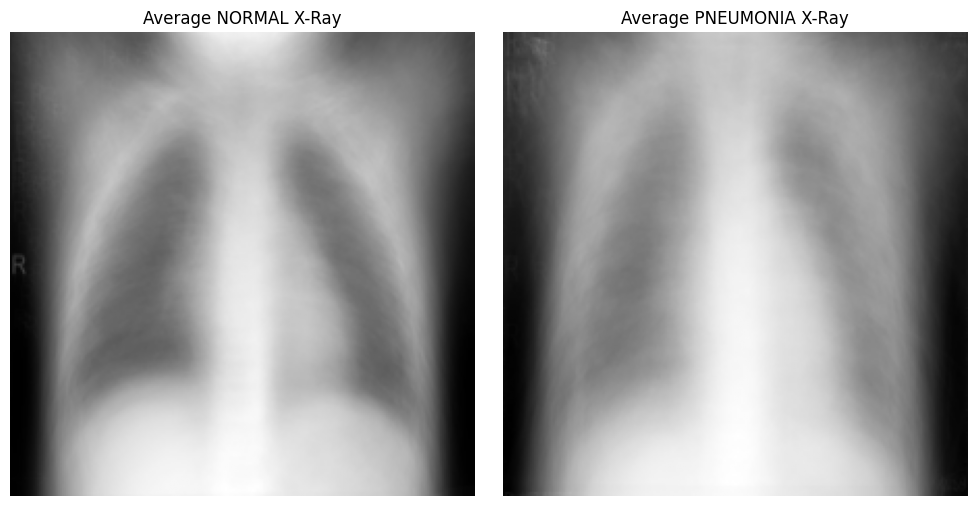

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    normal_average,
    cmap="gray"
)

plt.title("Average NORMAL X-Ray")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    pneumonia_average,
    cmap="gray"
)

plt.title("Average PNEUMONIA X-Ray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import ImageFilter

def denoise_image(image_path):

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        IMAGE_SIZE
    )

    image = image.filter(
        ImageFilter.GaussianBlur(
            radius=1
        )
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_array = image_array / 255.0

    return image_array

In [ ]:
original_image = preprocess_image(
    sample_normal_path
)

denoised_image = denoise_image(
    sample_normal_path
)

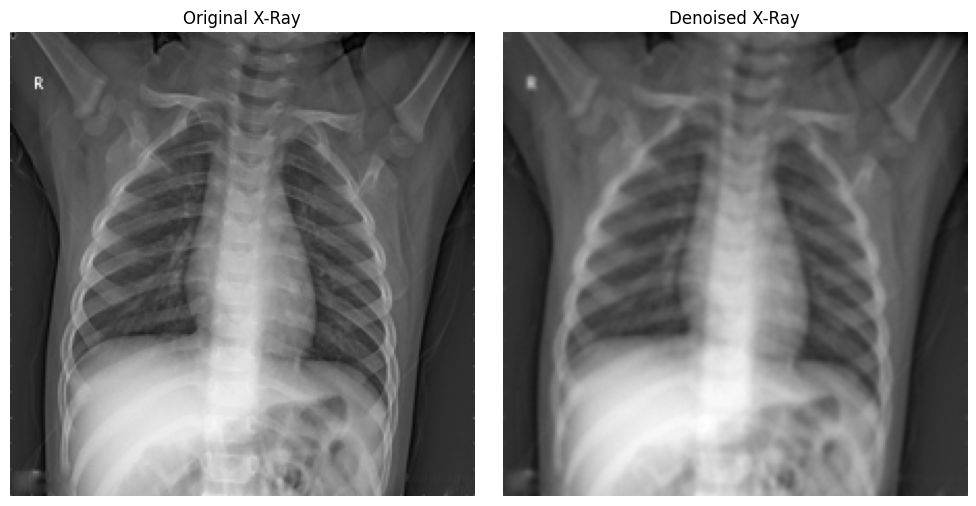

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    original_image,
    cmap="gray"
)

plt.title("Original X-Ray")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    denoised_image,
    cmap="gray"
)

plt.title("Denoised X-Ray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(
        0.05
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

print("Image augmentation pipeline created.")

Image augmentation pipeline created.


In [ ]:
sample_image = sample_batch_images[0]

sample_image_batch = tf.expand_dims(
    sample_image,
    axis=0
)

augmented_image = data_augmentation(
    sample_image_batch,
    training=True
)

augmented_image = augmented_image[0]

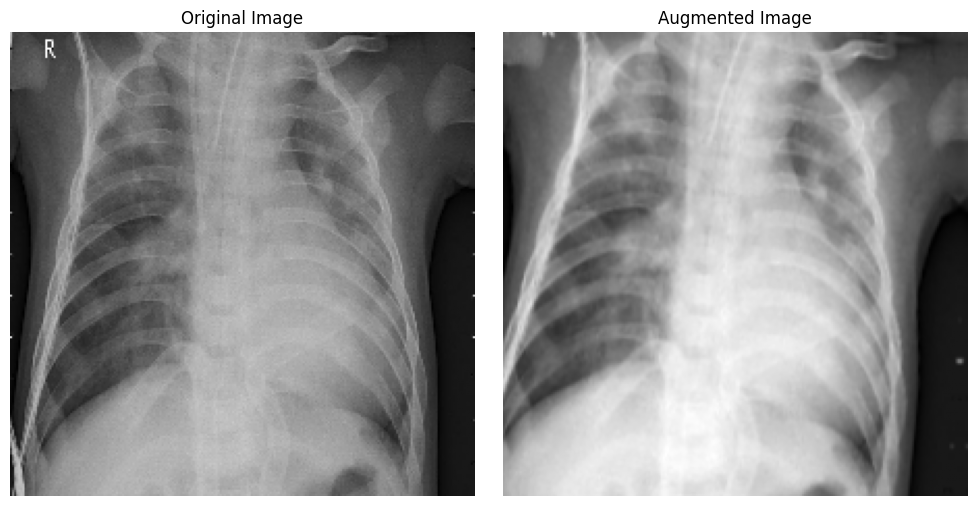

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    sample_image.numpy().squeeze(),
    cmap="gray"
)

plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    augmented_image.numpy().squeeze(),
    cmap="gray"
)

plt.title("Augmented Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_feature_images = np.concatenate([
    normal_sample_images,
    pneumonia_sample_images
])

image_feature_labels = np.concatenate([
    np.zeros(len(normal_sample_images)),
    np.ones(len(pneumonia_sample_images))
])

print(
    "Feature image data shape:",
    image_feature_images.shape
)

print(
    "Labels shape:",
    image_feature_labels.shape
)

Feature image data shape: (200, 224, 224)
Labels shape: (200,)


In [ ]:
image_features = pd.DataFrame({

    "Mean_Intensity":
        image_feature_images.mean(axis=(1, 2)),

    "Std_Intensity":
        image_feature_images.std(axis=(1, 2)),

    "Min_Intensity":
        image_feature_images.min(axis=(1, 2)),

    "Max_Intensity":
        image_feature_images.max(axis=(1, 2)),

    "Median_Intensity":
        np.median(
            image_feature_images,
            axis=(1, 2)
        ),

    "Class":
        image_feature_labels
})

display(image_features.head())

,Mean_Intensity,Std_Intensity,Min_Intensity,Max_Intensity,Median_Intensity,Class
0,0.287419,0.148490,0.0,0.717647,0.247059,0.0
1,0.538217,0.260487,0.0,1.000000,0.564706,0.0
2,0.479271,0.227463,0.0,0.984314,0.537255,0.0
3,0.557217,0.218551,0.0,0.984314,0.596078,0.0
4,0.420320,0.230866,0.0,1.000000,0.482353,0.0


In [ ]:
print("Statistical summary of engineered image features:")

display(
    image_features.describe()
)

Statistical summary of engineered image features:


,Mean_Intensity,Std_Intensity,Min_Intensity,Max_Intensity,Median_Intensity,Class
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.474110,0.227821,0.003039,0.946961,0.511608,0.500000
std,0.066433,0.035558,0.015465,0.069123,0.084643,0.501255
min,0.287419,0.125841,0.000000,0.701961,0.247059,0.000000
25%,0.436299,0.206927,0.000000,0.898039,0.461765,0.000000
50%,0.472706,0.229515,0.000000,0.984314,0.519608,0.500000
75%,0.513708,0.251327,0.000000,1.000000,0.560784,1.000000
max,0.734981,0.322511,0.180392,1.000000,0.792157,1.000000


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

X_image_features = image_features.drop(
    columns=["Class"]
)

y_image = image_features["Class"]

feature_selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

X_image_selected = feature_selector.fit_transform(
    X_image_features,
    y_image
)

In [ ]:
feature_selection_results = pd.DataFrame({

    "Feature":
        X_image_features.columns,

    "F_Score":
        feature_selector.scores_,

    "P_Value":
        feature_selector.pvalues_
})

display(
    feature_selection_results.sort_values(
        by="F_Score",
        ascending=False
    )
)

,Feature,F_Score,P_Value
3,Max_Intensity,47.068509,8.570891e-11
1,Std_Intensity,12.174359,5.970678e-04
2,Min_Intensity,7.995547,5.171051e-03
4,Median_Intensity,3.659043,5.720862e-02
0,Mean_Intensity,2.893038,9.053293e-02


In [ ]:
!pip -q install scikit-image

In [ ]:
from skimage.feature import hog

In [ ]:
hog_features = []

for image in image_feature_images:

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    hog_features.append(features)

X_hog = np.array(
    hog_features
)

print("HOG feature shape:")
print(X_hog.shape)

HOG feature shape:
(200, 6084)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

hog_scaler = StandardScaler()

X_hog_scaled = hog_scaler.fit_transform(
    X_hog
)

In [ ]:
pca = PCA(
    n_components=2
)

X_hog_pca = pca.fit_transform(
    X_hog_scaled
)

print("Original HOG feature shape:")
print(X_hog.shape)

print("\nPCA feature shape:")
print(X_hog_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(
    pca.explained_variance_ratio_.sum()
)

Original HOG feature shape:
(200, 6084)

PCA feature shape:
(200, 2)

Explained variance ratio:
[0.07888371 0.05006721]

Total explained variance:
0.12895092


In [ ]:
pca_image_df = pd.DataFrame(
    X_hog_pca,
    columns=["PC1", "PC2"]
)

pca_image_df["Class"] = image_feature_labels

pca_image_df["Class"] = (
    pca_image_df["Class"]
    .map({
        0: "NORMAL",
        1: "PNEUMONIA"
    })
)

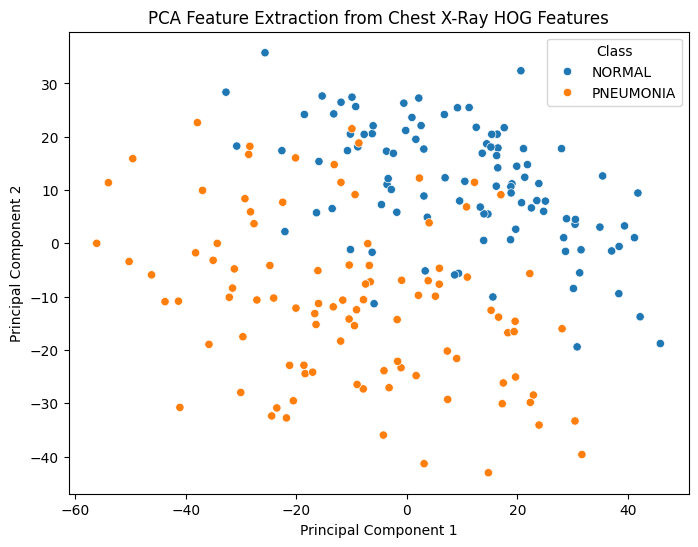

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_image_df,
    x="PC1",
    y="PC2",
    hue="Class"
)

plt.title(
    "PCA Feature Extraction from Chest X-Ray HOG Features"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
print("=" * 60)
print("FINAL MODEL-READY IMAGE DATA")
print("=" * 60)

print(
    "\nImage size:",
    IMAGE_SIZE
)

print(
    "\nTraining tensor batch shape:",
    sample_batch_images.shape
)

print(
    "\nTraining label batch shape:",
    sample_batch_labels.shape
)

print(
    "\nPixel value range:",
    float(tf.reduce_min(
        sample_batch_images
    )),
    "to",
    float(tf.reduce_max(
        sample_batch_images
    ))
)

print(
    "\nClass names:",
    train_dataset.class_names
)

print(
    "\nHOG feature shape:",
    X_hog.shape
)

print(
    "\nPCA feature shape:",
    X_hog_pca.shape
)

FINAL MODEL-READY IMAGE DATA

Image size: (224, 224)

Training tensor batch shape: (32, 224, 224, 1)

Training label batch shape: (32, 1)

Pixel value range: 0.0 to 1.0

Class names: ['NORMAL', 'PNEUMONIA']

HOG feature shape: (200, 6084)

PCA feature shape: (200, 2)


# MIT-BH Arrhythmia Dataset(Signal)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/Arrythmia Disease/mit-bih-arrhythmia-database-1.0.0.zip"

print("ZIP file exists:", os.path.exists(zip_path))
print("ZIP file path:", zip_path)

ZIP file exists: True
ZIP file path: /content/drive/MyDrive/Arrythmia Disease/mit-bih-arrhythmia-database-1.0.0.zip


In [ ]:
import zipfile
import os

extract_path = "/content/mitdb"

os.makedirs(
    extract_path,
    exist_ok=True
)

with zipfile.ZipFile(
    zip_path,
    "r"
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
print("Files and folders after extraction:")

for root, dirs, files in os.walk(extract_path):

    level = root.replace(
        extract_path,
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        indent + os.path.basename(root) + "/"
    )

    for file in files[:10]:

        print(
            indent + "    " + file
        )

Files and folders after extraction:
mitdb/
    mit-bih-arrhythmia-database-1.0.0/
        116.atr
        107.hea
        230.dat
        228.dat
        205.hea
        200.dat
        122.xws
        212.atr
        104.dat
        124.dat
        x_mitdb/
            x_223.hea
            x_231.dat
            x_123.atr
            x_115.dat
            x_232.dat
            x_108.atr
            x_111.dat
            x_222.dat
            x_111.hea
            x_121.dat
        mitdbdir/
            records.htm
            tables.htm
            mitdbdir.htm
            foreword.htm
            intro.htm
            src/
                title.gz
                tab.1
                exlist
                extext.gz
                domit
                contents.tr
                index.gz
                tab.4
                makelinks.pl
                intro.tr
            samples/
                2131448.xws
                2132558.xws
                2030500.xws
               

In [ ]:
record_files = []

for root, dirs, files in os.walk(
    extract_path
):

    for file in files:

        if file.lower().endswith(".hea"):

            record_files.append(
                os.path.join(
                    root,
                    file
                )
            )

print(
    "Number of ECG records found:",
    len(record_files)
)

print("\nFirst 10 record files:")

for file in record_files[:10]:
    print(file)

Number of ECG records found: 71

First 10 record files:
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/107.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/205.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/202.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/209.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/217.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/109.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/108.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/112.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/111.hea
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/100.hea


In [ ]:
record_100_path = None

for file in record_files:

    if os.path.basename(file) == "100.hea":

        record_100_path = os.path.splitext(
            file
        )[0]

        break

print("Record 100 path:")
print(record_100_path)

Record 100 path:
/content/mitdb/mit-bih-arrhythmia-database-1.0.0/100


In [ ]:
!pip -q install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.4 MB/s eta 0:00:00


In [ ]:
import wfdb
record = wfdb.rdrecord(
    record_100_path
)

print("ECG record loaded successfully.")

ECG record loaded successfully.


In [ ]:
annotation = wfdb.rdann(
    record_100_path,
    "atr"
)

print("ECG annotations loaded successfully.")

ECG annotations loaded successfully.


In [ ]:
print("Record name:",
      record.record_name)

print(
    "Sampling frequency:",
    record.fs,
    "Hz"
)

print(
    "Number of samples:",
    record.sig_len
)

print(
    "Number of channels:",
    record.n_sig
)

print(
    "Signal names:",
    record.sig_name
)

print(
    "Signal shape:",
    record.p_signal.shape
)

Record name: 100
Sampling frequency: 360 Hz
Number of samples: 650000
Number of channels: 2
Signal names: ['MLII', 'V5']
Signal shape: (650000, 2)


In [ ]:
ecg = record.p_signal[:, 0]

sampling_frequency = record.fs

print(
    "Selected ECG channel:",
    record.sig_name[0]
)

print(
    "Sampling frequency:",
    sampling_frequency,
    "Hz"
)

print(
    "Number of samples:",
    len(ecg)
)

Selected ECG channel: MLII
Sampling frequency: 360 Hz
Number of samples: 650000


In [ ]:
import numpy as np

time = np.arange(
    len(ecg)
) / sampling_frequency

print(
    "ECG duration:",
    time[-1],
    "seconds"
)

ECG duration: 1805.5527777777777 seconds


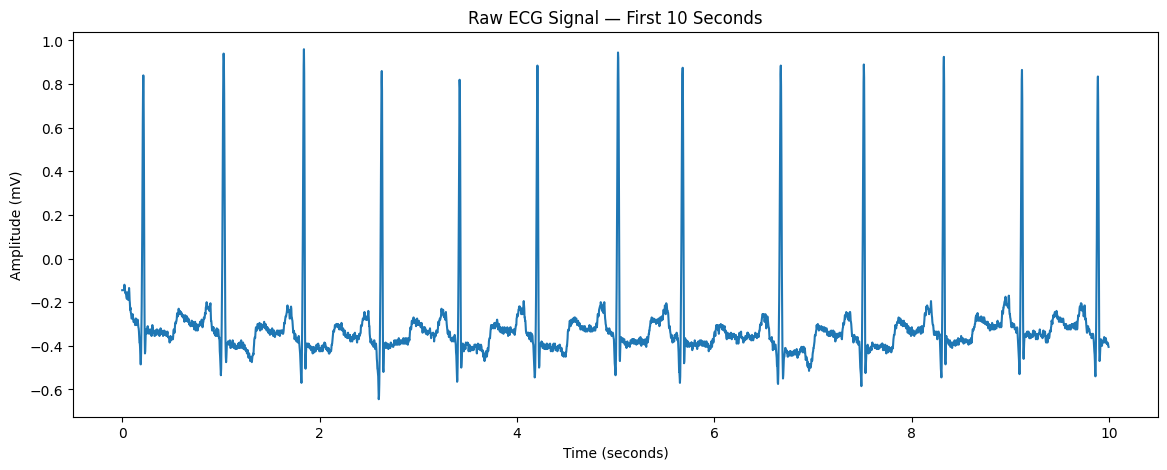

In [ ]:
import matplotlib.pyplot as plt

duration = 10

samples_to_plot = int(
    duration * sampling_frequency
)

plt.figure(figsize=(14, 5))

plt.plot(
    time[:samples_to_plot],
    ecg[:samples_to_plot]
)

plt.title(
    "Raw ECG Signal — First 10 Seconds"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude (mV)"
)

plt.show()

In [ ]:
print("ECG Signal Statistics")
print("---------------------")

print(
    "Minimum:",
    np.min(ecg)
)

print(
    "Maximum:",
    np.max(ecg)
)

print(
    "Mean:",
    np.mean(ecg)
)

print(
    "Standard deviation:",
    np.std(ecg)
)

ECG Signal Statistics
---------------------
Minimum: -2.715
Maximum: 1.435
Mean: -0.3062989769230769
Standard deviation: 0.19319954213721688


In [ ]:
print(
    "NaN values:",
    np.isnan(ecg).sum()
)

print(
    "Infinite values:",
    np.isinf(ecg).sum()
)

NaN values: 0
Infinite values: 0


In [ ]:
ecg_clean = ecg.copy()

if (
    np.isnan(ecg_clean).any()
    or
    np.isinf(ecg_clean).any()
):

    replacement_value = np.nanmedian(
        ecg_clean
    )

    ecg_clean = np.nan_to_num(
        ecg_clean,
        nan=replacement_value,
        posinf=replacement_value,
        neginf=replacement_value
    )

print(
    "NaN values after cleaning:",
    np.isnan(ecg_clean).sum()
)

print(
    "Infinite values after cleaning:",
    np.isinf(ecg_clean).sum()
)

NaN values after cleaning: 0
Infinite values after cleaning: 0


In [ ]:
print(
    "Number of annotations:",
    len(annotation.sample)
)

Number of annotations: 2274


In [ ]:
annotation_table = pd.DataFrame({

    "Sample":
        annotation.sample[:20],

    "Time":
        annotation.sample[:20]
        / sampling_frequency,

    "Symbol":
        annotation.symbol[:20]
})

display(
    annotation_table
)

,Sample,Time,Symbol
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


In [ ]:
beat_symbols = np.array(
    annotation.symbol
)

unique_symbols = sorted(
    set(beat_symbols)
)

print(
    "Unique ECG annotation symbols:"
)

print(
    unique_symbols
)

Unique ECG annotation symbols:
[np.str_('+'), np.str_('A'), np.str_('N'), np.str_('V')]


In [ ]:
import pandas as pd

beat_counts = pd.Series(
    beat_symbols
).value_counts()

print(
    "ECG annotation distribution:"
)

display(
    beat_counts
)

ECG annotation distribution:


,count
N,2239
A,33
+,1
V,1


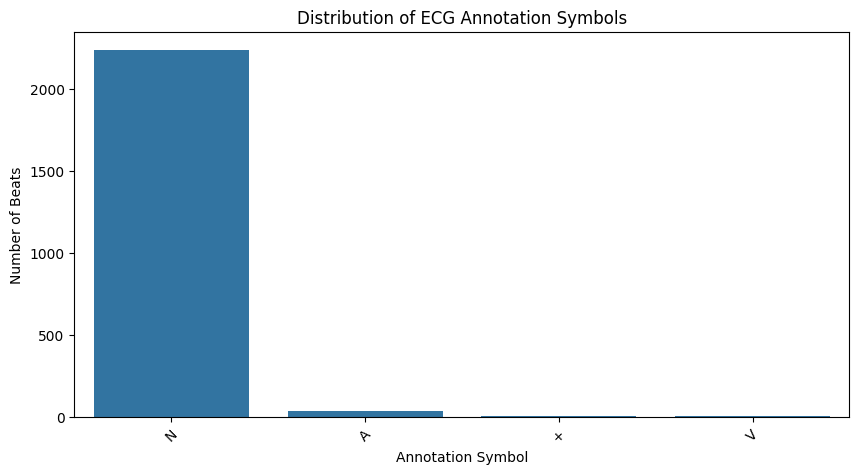

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    x=beat_counts.index,
    y=beat_counts.values
)

plt.title(
    "Distribution of ECG Annotation Symbols"
)

plt.xlabel(
    "Annotation Symbol"
)

plt.ylabel(
    "Number of Beats"
)

plt.xticks(
    rotation=45
)

plt.show()

In [ ]:
from scipy import signal

low_cutoff = 0.5
high_cutoff = 40.0

nyquist = sampling_frequency / 2

low = low_cutoff / nyquist
high = high_cutoff / nyquist

b, a = signal.butter(
    4,
    [low, high],
    btype="bandpass"
)

ecg_filtered = signal.filtfilt(
    b,
    a,
    ecg_clean
)

print(
    "ECG noise removal completed."
)

ECG noise removal completed.


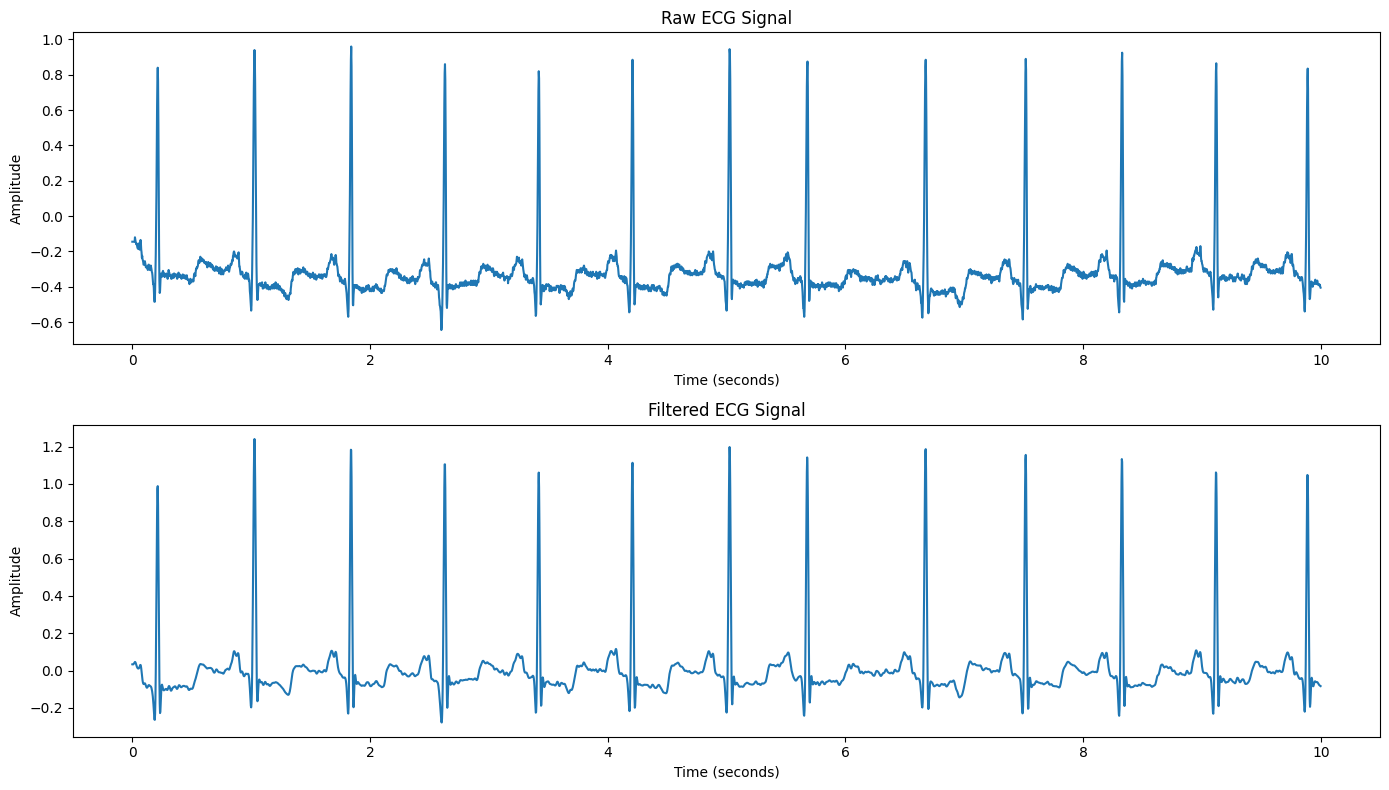

In [ ]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)

plt.plot(
    time[:samples_to_plot],
    ecg_clean[:samples_to_plot]
)

plt.title(
    "Raw ECG Signal"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")


plt.subplot(2, 1, 2)

plt.plot(
    time[:samples_to_plot],
    ecg_filtered[:samples_to_plot]
)

plt.title(
    "Filtered ECG Signal"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()

plt.show()

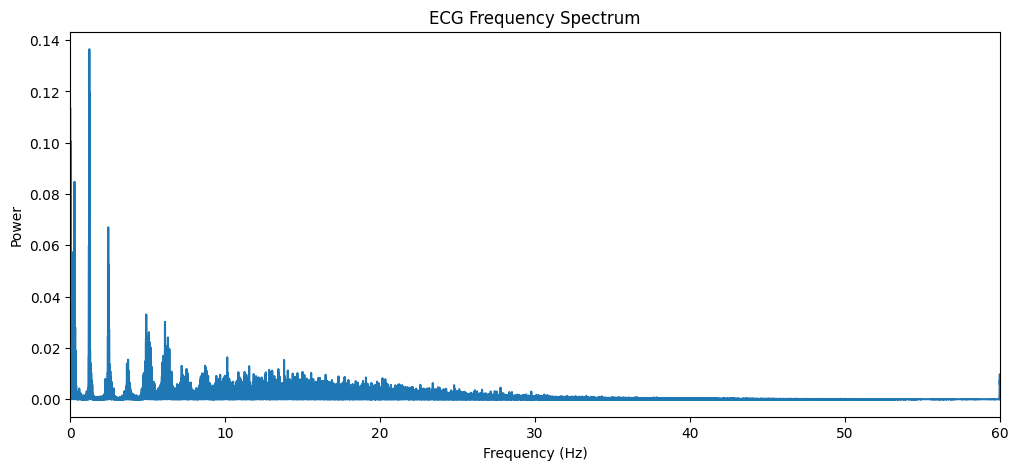

In [ ]:
frequencies, power = signal.periodogram(
    ecg_clean,
    fs=sampling_frequency
)


plt.figure(figsize=(12, 5))

plt.plot(
    frequencies,
    power
)

plt.xlim(
    0,
    60
)

plt.title(
    "ECG Frequency Spectrum"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Power"
)

plt.show()

In [ ]:
window_duration = 5

window_size = int(
    window_duration
    * sampling_frequency
)

print(
    "Sampling frequency:",
    sampling_frequency
)

print(
    "Window duration:",
    window_duration,
    "seconds"
)

print(
    "Samples per window:",
    window_size
)

Sampling frequency: 360
Window duration: 5 seconds
Samples per window: 1800


In [ ]:
windows = []

window_start_times = []

for start in range(
    0,
    len(ecg_filtered) - window_size + 1,
    window_size
):

    window = ecg_filtered[
        start:
        start + window_size
    ]

    windows.append(
        window
    )

    window_start_times.append(
        start / sampling_frequency
    )

windows = np.array(
    windows
)

print(
    "Signal windows shape:",
    windows.shape
)

Signal windows shape: (361, 1800)


In [ ]:
windows_normalized = np.zeros_like(
    windows,
    dtype=np.float32
)

for i in range(
    len(windows)
):

    mean = np.mean(
        windows[i]
    )

    std = np.std(
        windows[i]
    )

    if std > 0:

        windows_normalized[i] = (
            windows[i] - mean
        ) / std

    else:

        windows_normalized[i] = (
            windows[i] - mean
        )

print(
    "Normalized signal windows:",
    windows_normalized.shape
)

Normalized signal windows: (361, 1800)


In [ ]:
print("MODEL-READY ECG WINDOWS")
print("-----------------------")

print(
    "Number of windows:",
    windows_normalized.shape[0]
)

print(
    "Samples per window:",
    windows_normalized.shape[1]
)

print(
    "Minimum value:",
    windows_normalized.min()
)

print(
    "Maximum value:",
    windows_normalized.max()
)

MODEL-READY ECG WINDOWS
-----------------------
Number of windows: 361
Samples per window: 1800
Minimum value: -7.643253
Maximum value: 8.447131


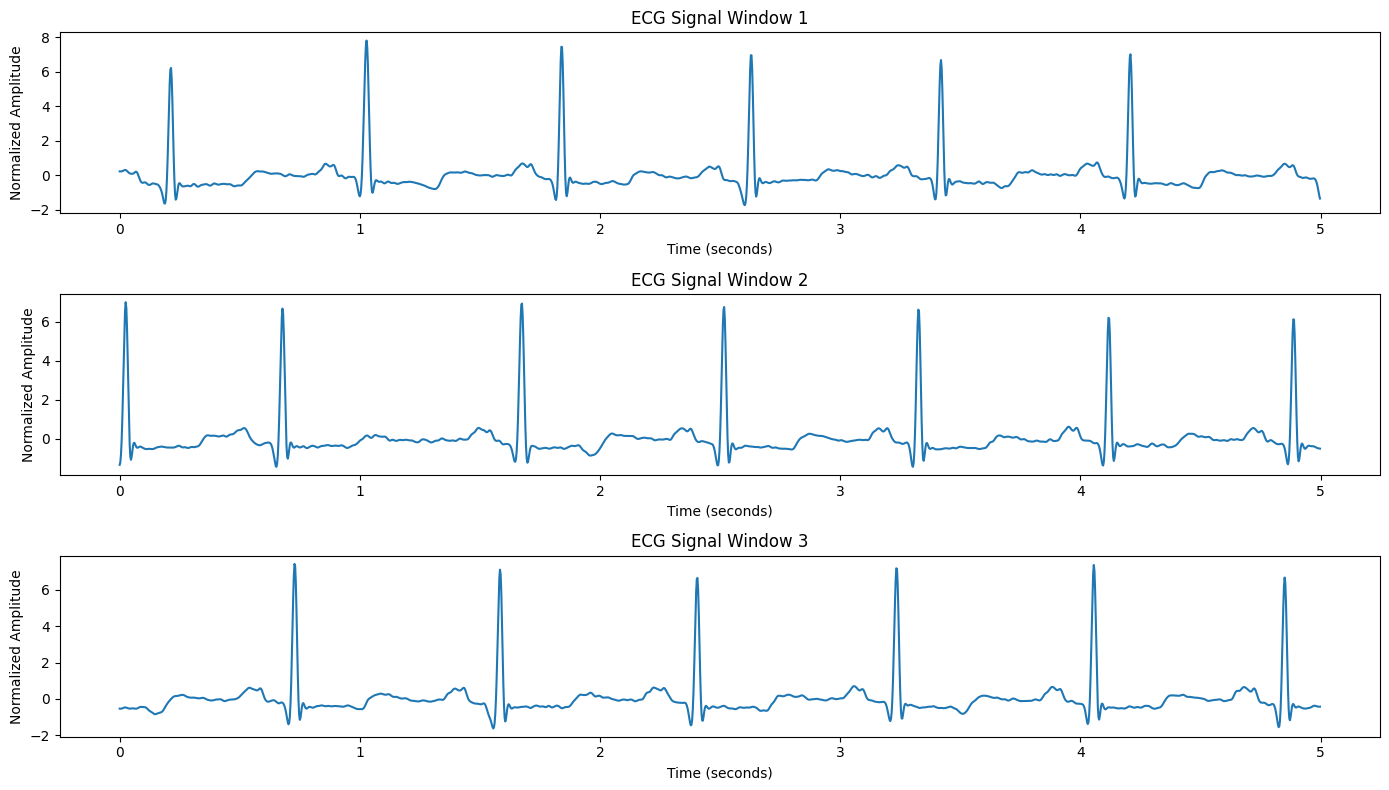

In [ ]:
plt.figure(figsize=(14, 8))

window_time = (
    np.arange(window_size)
    / sampling_frequency
)

for i in range(3):

    plt.subplot(
        3,
        1,
        i + 1
    )

    plt.plot(
        window_time,
        windows_normalized[i]
    )

    plt.title(
        f"ECG Signal Window {i + 1}"
    )

    plt.xlabel(
        "Time (seconds)"
    )

    plt.ylabel(
        "Normalized Amplitude"
    )

plt.tight_layout()

plt.show()

In [ ]:
beat_samples = np.array(
    annotation.sample
)

beat_symbols = np.array(
    annotation.symbol
)

rr_intervals = (
    np.diff(
        beat_samples
    )
    / sampling_frequency
)

print(
    "First 10 RR intervals:"
)

print(
    rr_intervals[:10]
)

First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [ ]:
heart_rates = (
    60 / rr_intervals
)

print(
    "First 10 estimated heart rates:"
)

print(
    heart_rates[:10]
)

print(
    "Mean heart rate:",
    np.mean(heart_rates)
)

print(
    "Minimum heart rate:",
    np.min(heart_rates)
)

print(
    "Maximum heart rate:",
    np.max(heart_rates)
)

First 10 estimated heart rates:
[366.10169492  73.72013652  73.97260274  76.05633803  75.78947368
  76.05633803  73.46938776  91.91489362  60.33519553  71.05263158]
Mean heart rate: 75.94458550403931
Minimum heart rate: 53.071253071253075
Maximum heart rate: 366.10169491525426


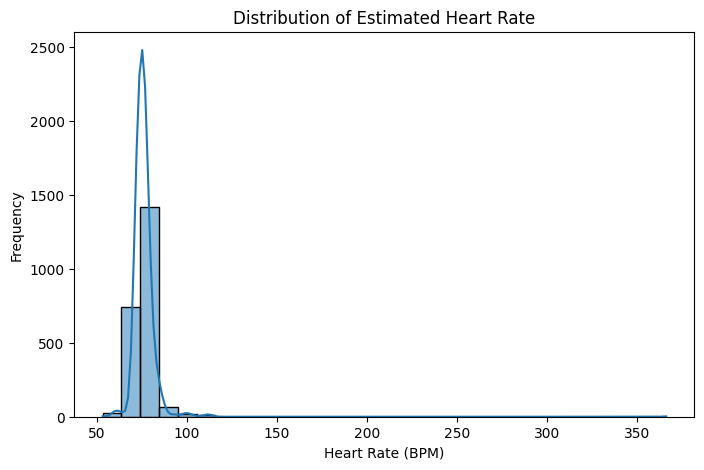

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    heart_rates,
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Estimated Heart Rate"
)

plt.xlabel(
    "Heart Rate (BPM)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [ ]:
ecg_features = pd.DataFrame({

    "Mean":
        np.mean(
            windows_normalized,
            axis=1
        ),

    "Std":
        np.std(
            windows_normalized,
            axis=1
        ),

    "Min":
        np.min(
            windows_normalized,
            axis=1
        ),

    "Max":
        np.max(
            windows_normalized,
            axis=1
        ),

    "Range":
        np.ptp(
            windows_normalized,
            axis=1
        ),

    "RMS":
        np.sqrt(
            np.mean(
                windows_normalized ** 2,
                axis=1
            )
        ),

    "Energy":
        np.sum(
            windows_normalized ** 2,
            axis=1
        )
})

display(
    ecg_features.head()
)

,Mean,Std,Min,Max,Range,RMS,Energy
0,-2.119276e-09,1.0,-1.725976,7.794051,9.520027,1.0,1800.0
1,0.000000e+00,1.0,-1.437585,7.003017,8.440601,1.0,1800.0
2,1.059638e-09,1.0,-1.616717,7.404169,9.020885,1.0,1800.0
3,-2.119276e-09,1.0,-1.447823,7.481812,8.929635,1.0,1800.0
4,2.119276e-09,1.0,-1.538691,7.740626,9.279316,1.0,1800.0


In [ ]:
display(
    ecg_features.describe()
)

,Mean,Std,Min,Max,Range,RMS,Energy
count,3.610000e+02,3.610000e+02,361.000000,361.000000,361.000000,3.610000e+02,361.000000
mean,1.152100e-10,1.000000e+00,-1.497787,7.485609,8.983395,1.000000e+00,1800.000000
std,2.805163e-09,1.473466e-08,0.364281,0.419369,0.446200,1.473466e-08,0.000038
min,-6.622738e-09,9.999999e-01,-7.643253,4.233064,7.879004,9.999999e-01,1799.999878
25%,-2.119276e-09,1.000000e+00,-1.566647,7.261634,8.719161,1.000000e+00,1800.000000
50%,0.000000e+00,1.000000e+00,-1.457808,7.496007,8.987236,1.000000e+00,1800.000000
75%,2.119276e-09,1.000000e+00,-1.368218,7.734399,9.216154,1.000000e+00,1800.000000
max,1.377530e-08,1.000000e+00,-1.125856,8.447131,11.876317,1.000000e+00,1800.000122


In [ ]:
window_labels = []

for start in range(
    0,
    len(ecg_filtered) - window_size + 1,
    window_size
):

    end = start + window_size

    mask = (
        (beat_samples >= start) &
        (beat_samples < end)
    )

    symbols_in_window = beat_symbols[mask]

    if len(symbols_in_window) == 0:

        window_labels.append(np.nan)

    elif np.any(symbols_in_window != "N"):

        # At least one abnormal beat
        window_labels.append(1)

    else:

        # All beats are normal
        window_labels.append(0)


window_labels = np.array(window_labels)

print("Window labels created.")

Window labels created.


In [ ]:
valid = ~np.isnan(window_labels)

y_features = (
    window_labels[valid]
    .astype(int)
)

print("Number of valid windows:",
      len(y_features))

print("\nUnique classes:")
print(np.unique(y_features))

print("\nClass distribution:")

class_distribution = pd.Series(
    y_features
).value_counts()

print(class_distribution)

Number of valid windows: 361

Unique classes:
[0 1]

Class distribution:
0    327
1     34
Name: count, dtype: int64


In [ ]:
X_windows_for_features = windows[valid]

print(
    "Feature window data shape:",
    X_windows_for_features.shape
)

Feature window data shape: (361, 1800)


In [ ]:
X_features = pd.DataFrame({

    "Mean":
        np.mean(
            X_windows_for_features,
            axis=1
        ),

    "Std":
        np.std(
            X_windows_for_features,
            axis=1
        ),

    "Min":
        np.min(
            X_windows_for_features,
            axis=1
        ),

    "Max":
        np.max(
            X_windows_for_features,
            axis=1
        ),

    "Range":
        np.ptp(
            X_windows_for_features,
            axis=1
        ),

    "RMS":
        np.sqrt(
            np.mean(
                X_windows_for_features ** 2,
                axis=1
            )
        ),

    "Energy":
        np.sum(
            X_windows_for_features ** 2,
            axis=1
        )
})

print("Feature matrix:")
display(X_features.head())

Feature matrix:


,Mean,Std,Min,Max,Range,RMS,Energy
0,-0.003194,0.159633,-0.278717,1.240993,1.519710,0.159665,45.887170
1,0.002878,0.170659,-0.242458,1.198003,1.440461,0.170683,52.438761
2,-0.001033,0.157981,-0.256442,1.168682,1.425124,0.157984,44.926039
3,-0.001912,0.168449,-0.245797,1.258394,1.504191,0.168460,51.081919
4,0.000060,0.170082,-0.261643,1.316599,1.578243,0.170082,52.070067


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

feature_selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

X_selected = feature_selector.fit_transform(
    X_features,
    y_features
)

In [ ]:
feature_selection_results = pd.DataFrame({

    "Feature":
        X_features.columns,

    "F_Score":
        feature_selector.scores_,

    "P_Value":
        feature_selector.pvalues_
})

print("Feature Selection Results:")

display(
    feature_selection_results
)

Feature Selection Results:


,Feature,F_Score,P_Value
0,Mean,0.142736,0.705799
1,Std,4.922757,0.027130
2,Min,9.177742,0.002627
3,Max,0.618954,0.431955
4,Range,6.778237,0.009610
5,RMS,4.926917,0.027066
6,Energy,5.964849,0.015076


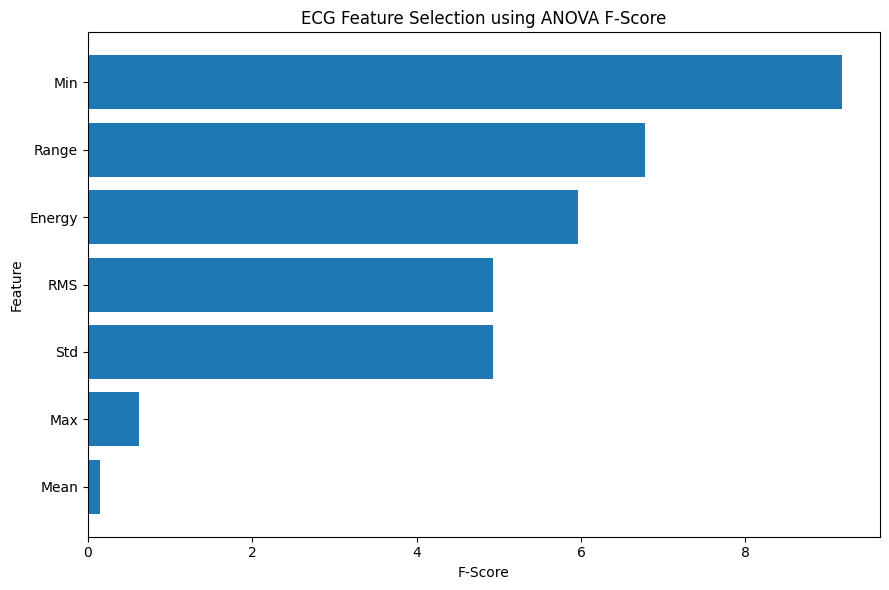

In [ ]:
plot_data = feature_selection_results.copy()

# Remove invalid scores
plot_data = plot_data.replace(
    [np.inf, -np.inf],
    np.nan
)

plot_data = plot_data.dropna(
    subset=["F_Score"]
)

plot_data = plot_data.sort_values(
    by="F_Score",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["F_Score"]
)

plt.title(
    "ECG Feature Selection using ANOVA F-Score"
)

plt.xlabel(
    "F-Score"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_scaler = StandardScaler()

X_features_scaled = (
    feature_scaler.fit_transform(
        X_features
    )
)

In [ ]:
pca = PCA(
    n_components=2
)

X_ecg_pca = pca.fit_transform(
    X_features_scaled
)

print(
    "Original feature shape:",
    X_features.shape
)

print(
    "PCA feature shape:",
    X_ecg_pca.shape
)

print(
    "\nExplained variance ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "\nTotal explained variance:"
)

print(
    pca.explained_variance_ratio_.sum()
)

Original feature shape: (361, 7)
PCA feature shape: (361, 2)

Explained variance ratio:
[0.67330207 0.15268435]

Total explained variance:
0.8259864250960081


In [ ]:
pca_ecg_df = pd.DataFrame(
    X_ecg_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_ecg_df["Class"] = (
    y_features
)

pca_ecg_df["Class"] = (
    pca_ecg_df["Class"]
    .map({
        0: "Normal",
        1: "Abnormal"
    })
)

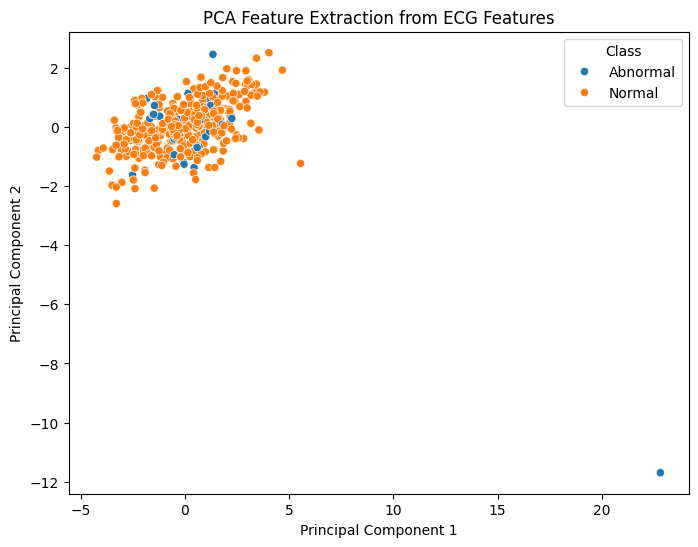

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_ecg_df,
    x="PC1",
    y="PC2",
    hue="Class"
)

plt.title(
    "PCA Feature Extraction from ECG Features"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

In [ ]:
def augment_ecg_window(
    window,
    noise_level=0.01
):

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=window.shape
    )

    augmented = (
        window + noise
    )

    return augmented

In [ ]:
original_window = (
    windows_normalized[0]
)

augmented_window = (
    augment_ecg_window(
        original_window,
        noise_level=0.01
    )
)

print(
    "Original window shape:",
    original_window.shape
)

print(
    "Augmented window shape:",
    augmented_window.shape
)

Original window shape: (1800,)
Augmented window shape: (1800,)


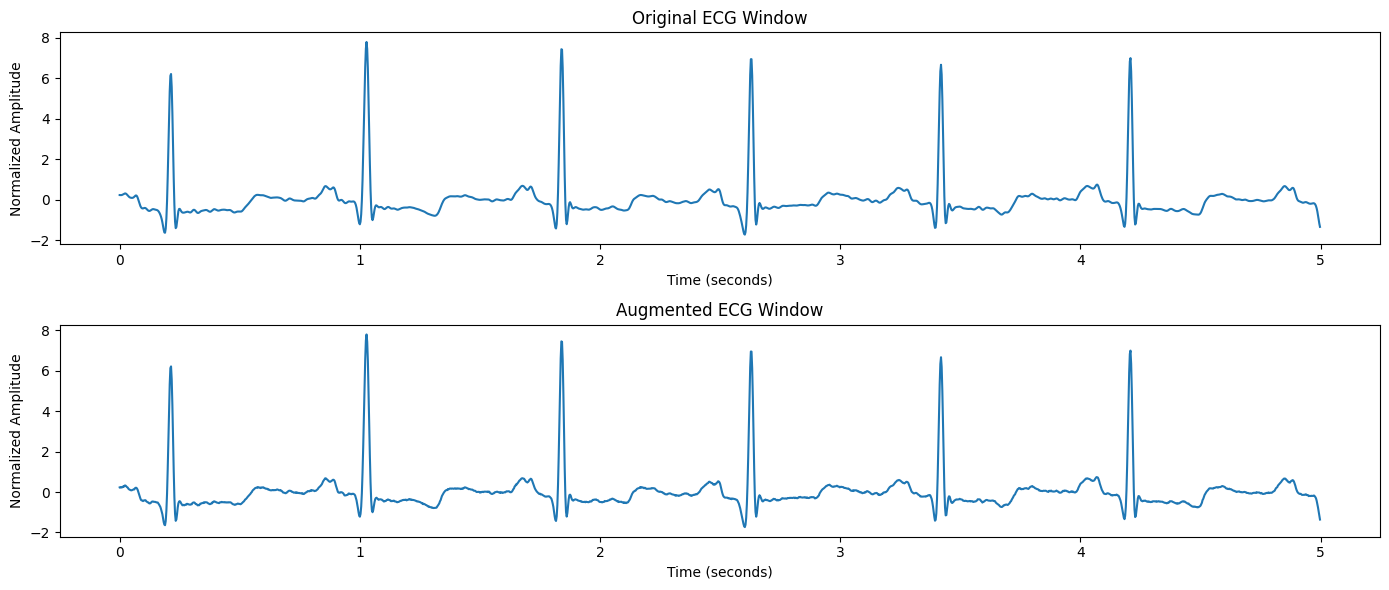

In [ ]:
window_time = (
    np.arange(window_size)
    / sampling_frequency
)

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)

plt.plot(
    window_time,
    original_window
)

plt.title(
    "Original ECG Window"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Normalized Amplitude"
)


plt.subplot(2, 1, 2)

plt.plot(
    window_time,
    augmented_window
)

plt.title(
    "Augmented ECG Window"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Normalized Amplitude"
)

plt.tight_layout()

plt.show()

In [ ]:
num_augmented = min(
    100,
    len(windows_normalized)
)

augmented_windows = []

for i in range(
    num_augmented
):

    augmented = (
        augment_ecg_window(
            windows_normalized[i],
            noise_level=0.01
        )
    )

    augmented_windows.append(
        augmented
    )

augmented_windows = np.array(
    augmented_windows
)

print(
    "Augmented ECG windows shape:"
)

print(
    augmented_windows.shape
)

Augmented ECG windows shape:
(100, 1800)


In [ ]:
X_signal = (
    windows_normalized[
        valid
    ]
)

X_signal = (
    X_signal[
        ..., np.newaxis
    ]
)

y_signal = y_features

print(
    "Final ECG signal tensor shape:",
    X_signal.shape
)

print(
    "Final label shape:",
    y_signal.shape
)

Final ECG signal tensor shape: (361, 1800, 1)
Final label shape: (361,)


In [ ]:
print("FINAL PART D — MIT-BIH ECG DATA")
print("=" * 60)

print(
    "\nSampling frequency:",
    sampling_frequency,
    "Hz"
)

print(
    "\nOriginal ECG samples:",
    len(ecg)
)

print(
    "\nECG duration:",
    time[-1],
    "seconds"
)

print(
    "\nSignal window duration:",
    window_duration,
    "seconds"
)

print(
    "\nSamples per signal window:",
    window_size
)

print(
    "\nFinal ECG tensor shape:",
    X_signal.shape
)

print(
    "\nFinal label shape:",
    y_signal.shape
)

print(
    "\nNumber of engineered features:",
    X_features.shape[1]
)

print(
    "\nPCA feature shape:",
    X_ecg_pca.shape
)

print(
    "\nAugmented windows shape:",
    augmented_windows.shape
)

print(
    "\nNaN values in final tensor:",
    np.isnan(X_signal).sum()
)

print(
    "\nInfinite values in final tensor:",
    np.isinf(X_signal).sum()
)

FINAL PART D — MIT-BIH ECG DATA

Sampling frequency: 360 Hz

Original ECG samples: 650000

ECG duration: 1805.5527777777777 seconds

Signal window duration: 5 seconds

Samples per signal window: 1800

Final ECG tensor shape: (361, 1800, 1)

Final label shape: (361,)

Number of engineered features: 7

PCA feature shape: (361, 2)

Augmented windows shape: (100, 1800)

NaN values in final tensor: 0

Infinite values in final tensor: 0


In [ ]:
wfdb.rdrecord("100", pn_dir="mitdb")